# CIND 860 Project
# Francis Semenuk
# 500185004

In [ ]:
import pandas as pd
from patsy import dmatrices
import numpy as np
import os
import matplotlib.pyplot as plt

import statsmodels.discrete.discrete_model as sm
import io
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from IPython.display import Image
from sklearn.tree import export_graphviz
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/mp2prt-all-clinical-data.tsv', sep='\t')
display(df.head())

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,MP2PRT-ALL,00318ddd-89bc-4a35-af79-5ab407fbd278,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUUDV,...,'--,'--,'--,'--,294e4f48-3ce9-4269-af5f-4d0f0eea4554,'--,'--,Complete Response,'--,'--
1,MP2PRT-ALL,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PATFUR,...,'--,'--,'--,'--,bd056554-f845-4b7f-938e-609ae391fe16,'--,'--,Complete Response,'--,'--
2,MP2PRT-ALL,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUXHS,...,'--,'--,'--,'--,38f79e51-11ef-4ebd-8573-90c6077f1802,'--,'--,Complete Response,'--,'--
3,MP2PRT-ALL,00d973d4-9eb1-4e77-a02b-ce4d954f9624,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PARRXA,...,'--,'--,'--,'--,f9b6e64f-7358-440c-bcbc-6c4f449c6dda,'--,'--,Complete Response,'--,'--
4,MP2PRT-ALL,00ef4e4f-a44b-467c-923c-3c001abdaa5d,'--,'--,'--,Acute Lymphoblastic Leukemia,'--,'--,Hematopoietic and reticuloendothelial systems,MP2PRT-PATKHY,...,'--,'--,'--,'--,fbc51cfa-1645-49f1-990b-74a977b2b064,'--,'--,Complete Response,'--,'--


In [ ]:
df.describe()

,demographic.age_at_index,demographic.days_to_birth,demographic.year_of_birth,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles
count,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000
mean,4.237086,-1729.721854,2004.847020,1729.721854,3044.868212,2009.587417,712.963576,2.114570,4.395364
std,2.694658,978.574173,3.643823,978.574173,835.479911,2.477996,456.459726,1.762427,2.037581
min,1.000000,-10670.000000,1983.000000,371.000000,254.000000,2004.000000,26.000000,0.000000,1.000000
25%,2.000000,-2151.500000,2003.000000,1064.500000,2548.250000,2007.000000,224.250000,1.000000,3.000000
50%,4.000000,-1488.500000,2005.000000,1488.500000,3051.000000,2010.000000,825.000000,2.000000,5.000000
75%,5.000000,-1064.500000,2008.000000,2151.500000,3724.500000,2012.000000,1179.000000,3.000000,6.000000
max,29.000000,-371.000000,2012.000000,10670.000000,5505.000000,2013.000000,1308.000000,32.000000,8.000000


In [ ]:
# Replace all '-- with NaN

df_temp = df.replace("'--", np.nan) # Create a temporary DataFrame for the operation, replacing ''--' with NaN
columns_to_drop = [col for col in df_temp.columns if df_temp[col].isnull().all()]

if columns_to_drop:
    print(f"Columns with only ''--' values (converted to NaN) to be dropped: {columns_to_drop}")
    df = df.drop(columns=columns_to_drop)
    print("Columns dropped successfully.")
else:
    print("No columns found with only ''--' values.")

Columns with only ''--' values (converted to NaN) to be dropped: ['cases.consent_type', 'cases.days_to_consent', 'cases.days_to_lost_to_followup', 'cases.index_date', 'cases.lost_to_followup', 'demographic.age_is_obfuscated', 'demographic.cause_of_death', 'demographic.cause_of_death_source', 'demographic.country_of_birth', 'demographic.education_level', 'demographic.marital_status', 'demographic.occupation_duration_years', 'demographic.population_group', 'diagnoses.adrenal_hormone', 'diagnoses.ajcc_clinical_m', 'diagnoses.ajcc_clinical_n', 'diagnoses.ajcc_clinical_stage', 'diagnoses.ajcc_clinical_t', 'diagnoses.ajcc_pathologic_m', 'diagnoses.ajcc_pathologic_n', 'diagnoses.ajcc_pathologic_stage', 'diagnoses.ajcc_pathologic_t', 'diagnoses.ajcc_serum_tumor_markers', 'diagnoses.ajcc_staging_system_edition', 'diagnoses.ann_arbor_b_symptoms', 'diagnoses.ann_arbor_b_symptoms_described', 'diagnoses.ann_arbor_clinical_stage', 'diagnoses.ann_arbor_extranodal_involvement', 'diagnoses.ann_arbor_pa

/tmp/ipykernel_794/970788864.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = df.replace("'--", np.nan) # Create a temporary DataFrame for the operation, replacing ''--' with NaN


In [ ]:
print("DataFrame shape after dropping null columns:", df.shape)
display(df.head())

DataFrame shape after dropping null columns: (1510, 37)


,project.project_id,cases.case_id,cases.disease_type,cases.primary_site,cases.submitter_id,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.demographic_id,...,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.initial_disease_status,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.submitter_id,treatments.treatment_anatomic_sites,treatments.treatment_id,treatments.treatment_outcome
0,MP2PRT-ALL,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUUDV,6,United States,-2231,'--,f989cf67-725b-4eb0-9c2b-67aeb4491fb8,...,810,1,Initial Diagnosis,6,Course of Therapy Completed,B-ALL Average Risk - Arm B Maintenance Therapy,MP2PRT-PAUUDV_trt,"Body, total",294e4f48-3ce9-4269-af5f-4d0f0eea4554,Complete Response
1,MP2PRT-ALL,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PATFUR,6,United States,-2492,1270,b4856672-d38d-45c1-8539-58c235f96c88,...,821,1,Initial Diagnosis,5,Course of Therapy Completed,SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MT...,MP2PRT-PATFUR_trt,"Body, total",bd056554-f845-4b7f-938e-609ae391fe16,Complete Response
2,MP2PRT-ALL,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PAUXHS,2,United States,-1026,'--,17b6fe1d-3672-4f79-8b95-73968dd62200,...,42,1,Initial Diagnosis,1,Other,B-ALL Non-Down Syndrome Induction Therapy,MP2PRT-PAUXHS_trt,"Body, total",38f79e51-11ef-4ebd-8573-90c6077f1802,Complete Response
3,MP2PRT-ALL,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PARRXA,15,United States,-5675,'--,e1f16b36-a41c-49a9-a946-3e613f137bc2,...,862,2,Initial Diagnosis,5,Course of Therapy Completed,"(PC) 4 weeks Prednisone during Induction, Cap...",MP2PRT-PARRXA_trt,"Body, total",f9b6e64f-7358-440c-bcbc-6c4f449c6dda,Complete Response
4,MP2PRT-ALL,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,Hematopoietic and reticuloendothelial systems,MP2PRT-PATKHY,2,United States,-1040,'--,2e12ddfd-ccd6-4b2a-b12f-9b574059c004,...,794,1,Initial Diagnosis,5,Course of Therapy Completed,SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI...,MP2PRT-PATKHY_trt,"Body, total",fbc51cfa-1645-49f1-990b-74a977b2b064,Complete Response


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   project.project_id                              1510 non-null   object 
 1   cases.case_id                                   1510 non-null   object 
 2   cases.disease_type                              1510 non-null   object 
 3   cases.primary_site                              1510 non-null   object 
 4   cases.submitter_id                              1510 non-null   object 
 5   demographic.age_at_index                        1510 non-null   int64  
 6   demographic.country_of_residence_at_enrollment  1510 non-null   object 
 7   demographic.days_to_birth                       1510 non-null   int64  
 8   demographic.days_to_death                       1510 non-null   object 
 9   demographic.demographic_id               

In [ ]:
# Find distinct categories for each column
print("Number of distinct categories for each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Number of distinct categories for each column:
project.project_id: 1 unique values
cases.case_id: 1510 unique values
cases.disease_type: 2 unique values
cases.primary_site: 1 unique values
cases.submitter_id: 1510 unique values
demographic.age_at_index: 20 unique values
demographic.country_of_residence_at_enrollment: 8 unique values
demographic.days_to_birth: 1167 unique values
demographic.days_to_death: 134 unique values
demographic.demographic_id: 1510 unique values
demographic.ethnicity: 3 unique values
demographic.gender: 2 unique values
demographic.race: 6 unique values
demographic.sex_at_birth: 2 unique values
demographic.submitter_id: 1510 unique values
demographic.vital_status: 3 unique values
demographic.year_of_birth: 25 unique values
demographic.year_of_death: 15 unique values
diagnoses.age_at_diagnosis: 1167 unique values
diagnoses.days_to_last_follow_up: 1163 unique values
diagnoses.diagnosis_id: 1510 unique values
diagnoses.morphology: 11 unique values
diagnoses.primary_d

In [ ]:
# Remove columns that only have a singular value
columns_to_drop_single_category = [col for col in df.columns if df[col].nunique() == 1]

if columns_to_drop_single_category:
    print(f"Columns with only one unique category to be dropped: {columns_to_drop_single_category}")
    df = df.drop(columns=columns_to_drop_single_category)
    print("Columns dropped successfully.")
else:
    print("No columns found with only one unique category.")

print("DataFrame shape after dropping single category columns:", df.shape)
display(df.head())

Columns with only one unique category to be dropped: ['project.project_id', 'cases.primary_site', 'treatments.initial_disease_status', 'treatments.treatment_anatomic_sites']
Columns dropped successfully.
DataFrame shape after dropping single category columns: (1510, 33)


,cases.case_id,cases.disease_type,cases.submitter_id,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.demographic_id,demographic.ethnicity,demographic.gender,...,diagnoses.tissue_or_organ_of_origin,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.submitter_id,treatments.treatment_id,treatments.treatment_outcome
0,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,MP2PRT-PAUUDV,6,United States,-2231,'--,f989cf67-725b-4eb0-9c2b-67aeb4491fb8,not hispanic or latino,female,...,Bone marrow,2012,810,1,6,Course of Therapy Completed,B-ALL Average Risk - Arm B Maintenance Therapy,MP2PRT-PAUUDV_trt,294e4f48-3ce9-4269-af5f-4d0f0eea4554,Complete Response
1,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,MP2PRT-PATFUR,6,United States,-2492,1270,b4856672-d38d-45c1-8539-58c235f96c88,not hispanic or latino,female,...,Bone marrow,2010,821,1,5,Course of Therapy Completed,SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MT...,MP2PRT-PATFUR_trt,bd056554-f845-4b7f-938e-609ae391fe16,Complete Response
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,MP2PRT-PAUXHS,2,United States,-1026,'--,17b6fe1d-3672-4f79-8b95-73968dd62200,not hispanic or latino,female,...,Bone marrow,2012,42,1,1,Other,B-ALL Non-Down Syndrome Induction Therapy,MP2PRT-PAUXHS_trt,38f79e51-11ef-4ebd-8573-90c6077f1802,Complete Response
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,MP2PRT-PARRXA,15,United States,-5675,'--,e1f16b36-a41c-49a9-a946-3e613f137bc2,not hispanic or latino,female,...,Bone marrow,2007,862,2,5,Course of Therapy Completed,"(PC) 4 weeks Prednisone during Induction, Cap...",MP2PRT-PARRXA_trt,f9b6e64f-7358-440c-bcbc-6c4f449c6dda,Complete Response
4,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,MP2PRT-PATKHY,2,United States,-1040,'--,2e12ddfd-ccd6-4b2a-b12f-9b574059c004,hispanic or latino,female,...,Bone marrow,2010,794,1,5,Course of Therapy Completed,SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI...,MP2PRT-PATKHY_trt,fbc51cfa-1645-49f1-990b-74a977b2b064,Complete Response


In [ ]:
# Drop columns that have unique values for every row, except for the case_id column to keep for a unique identifier

num_rows = df.shape[0]
columns_to_drop_unique_per_row = [col for col in df.columns if df[col].nunique() == num_rows and col != 'cases.case_id']

if columns_to_drop_unique_per_row:
    print(f"Columns with a unique value for each row (excluding 'cases.case_id') to be dropped: {columns_to_drop_unique_per_row}")
    df = df.drop(columns=columns_to_drop_unique_per_row)
    print("Columns dropped successfully.")
else:
    print("No columns found with a unique value for each row (excluding 'cases.case_id').")

print("DataFrame shape after dropping unique-per-row columns:", df.shape)
display(df.head())

Columns with a unique value for each row (excluding 'cases.case_id') to be dropped: ['cases.submitter_id', 'demographic.demographic_id', 'demographic.submitter_id', 'diagnoses.diagnosis_id', 'diagnoses.submitter_id', 'treatments.submitter_id', 'treatments.treatment_id']
Columns dropped successfully.
DataFrame shape after dropping unique-per-row columns: (1510, 26)


,cases.case_id,cases.disease_type,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.ethnicity,demographic.gender,demographic.race,demographic.sex_at_birth,...,diagnoses.primary_diagnosis,diagnoses.site_of_resection_or_biopsy,diagnoses.tissue_or_organ_of_origin,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.treatment_outcome
0,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,6,United States,-2231,'--,not hispanic or latino,female,black or african american,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2012,810,1,6,Course of Therapy Completed,B-ALL Average Risk - Arm B Maintenance Therapy,Complete Response
1,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,6,United States,-2492,1270,not hispanic or latino,female,white,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2010,821,1,5,Course of Therapy Completed,SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MT...,Complete Response
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,2,United States,-1026,'--,not hispanic or latino,female,white,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2012,42,1,1,Other,B-ALL Non-Down Syndrome Induction Therapy,Complete Response
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,15,United States,-5675,'--,not hispanic or latino,female,white,female,...,"Leukemia, NOS",Bone marrow,Bone marrow,2007,862,2,5,Course of Therapy Completed,"(PC) 4 weeks Prednisone during Induction, Cap...",Complete Response
4,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,2,United States,-1040,'--,hispanic or latino,female,white,female,...,Common precursor B ALL,Bone marrow,Bone marrow,2010,794,1,5,Course of Therapy Completed,SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI...,Complete Response


In [ ]:
# Identify missingness in each column (as identified by '--)

df = df.replace("'--", np.nan)
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = percent_missing.reset_index(name='percent_missing')
missing_value_df = missing_value_df.rename(columns={'index': 'column_name'})
missing_value_df

,column_name,percent_missing
0,cases.case_id,0.000000
1,cases.disease_type,0.000000
2,demographic.age_at_index,0.000000
3,demographic.country_of_residence_at_enrollment,0.000000
4,demographic.days_to_birth,0.000000
5,demographic.days_to_death,90.993377
6,demographic.ethnicity,0.000000
7,demographic.gender,0.000000
8,demographic.race,0.000000
9,demographic.sex_at_birth,0.000000


It is expected to have many blanks for demographic.days_to_death and demographic.year_of_death. The column treatments.reason_treatment_ended will need to have imputed values. Will need to identify if there is commonality with the data points.

Generating category distribution plots and counts:


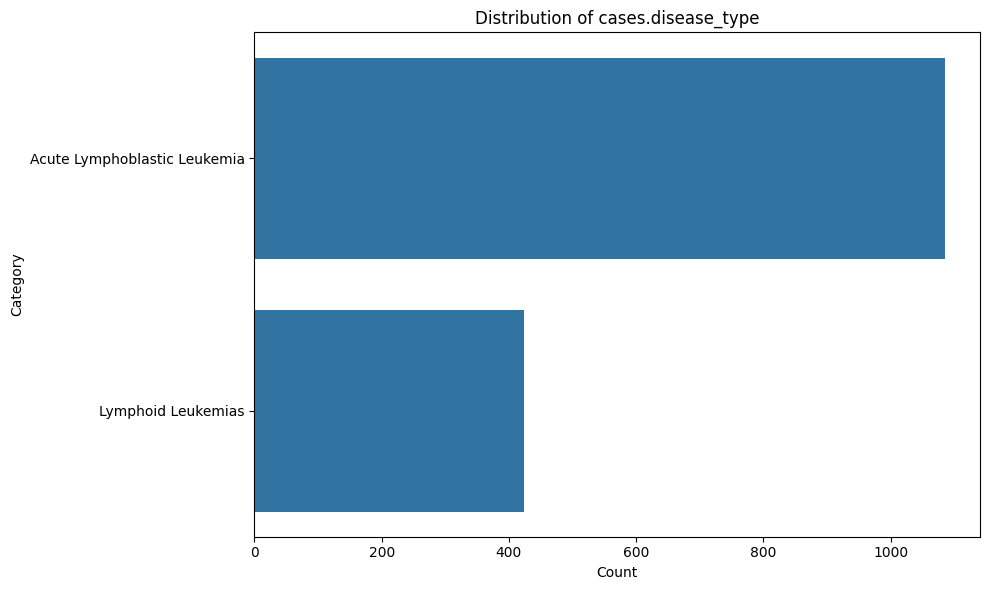

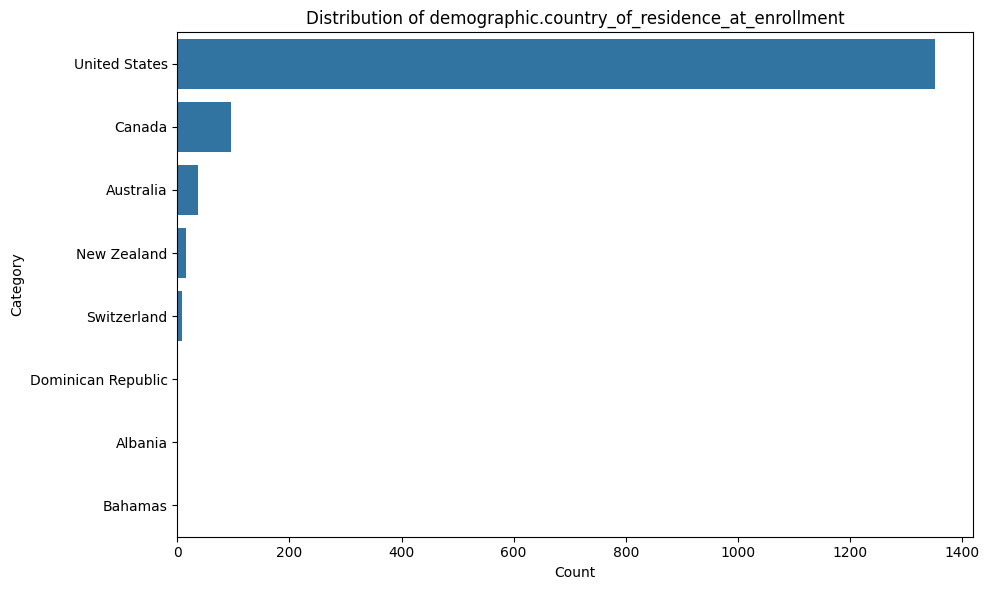


Column 'demographic.days_to_death' has 133 unique values (exceeds threshold 30). Printing value counts instead of plotting:
demographic.days_to_death
1165    2
611     2
1002    2
1620    1
1270    1
       ..
927     1
1817    1
994     1
2640    1
1341    1
Name: count, Length: 133, dtype: int64


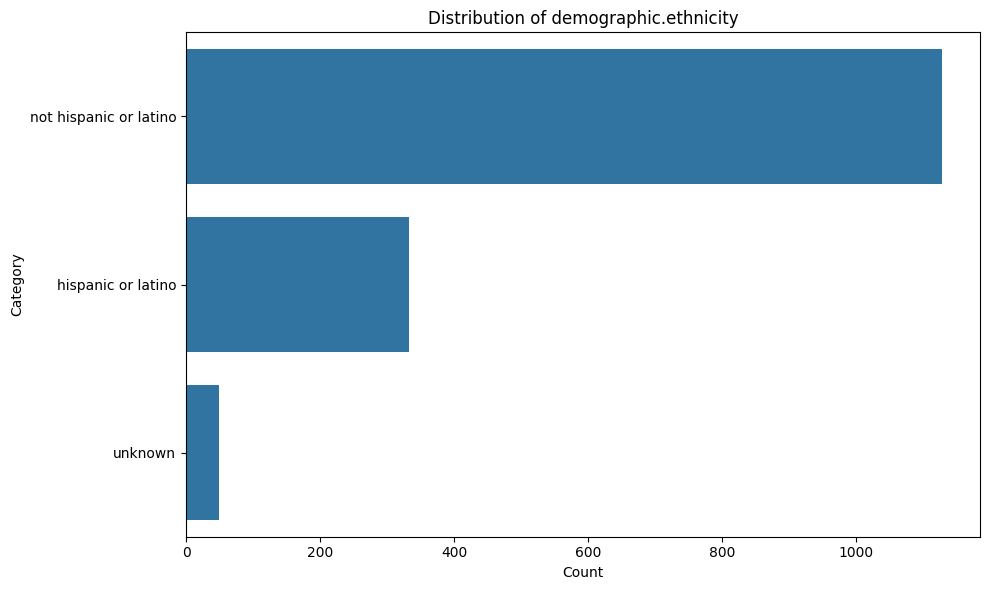

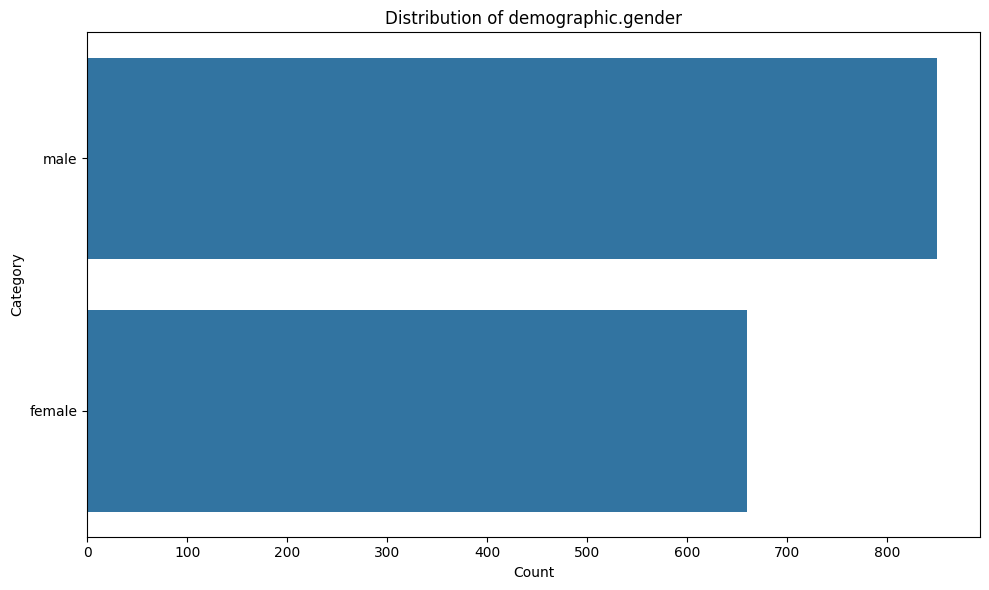

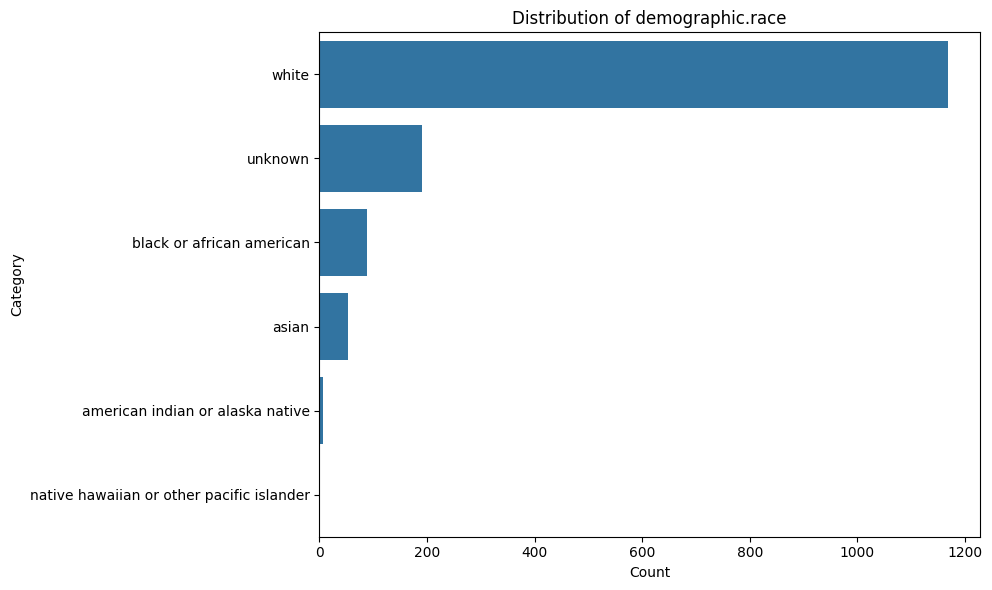

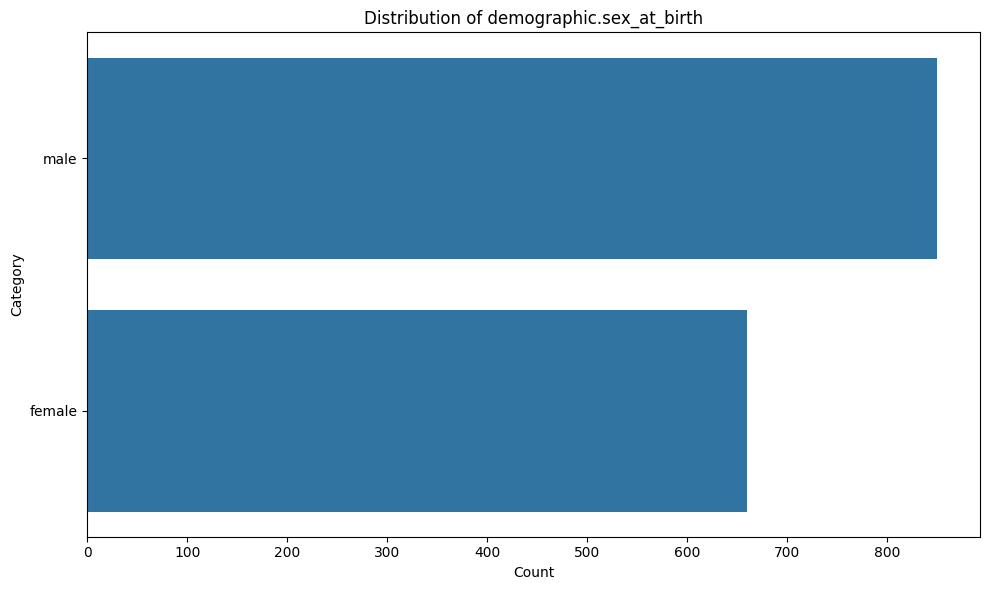

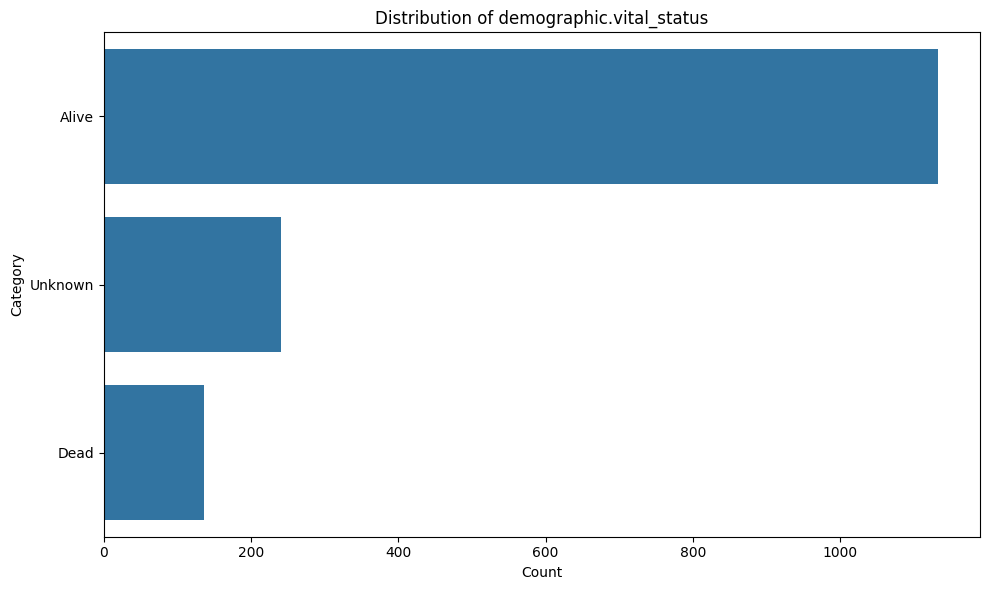

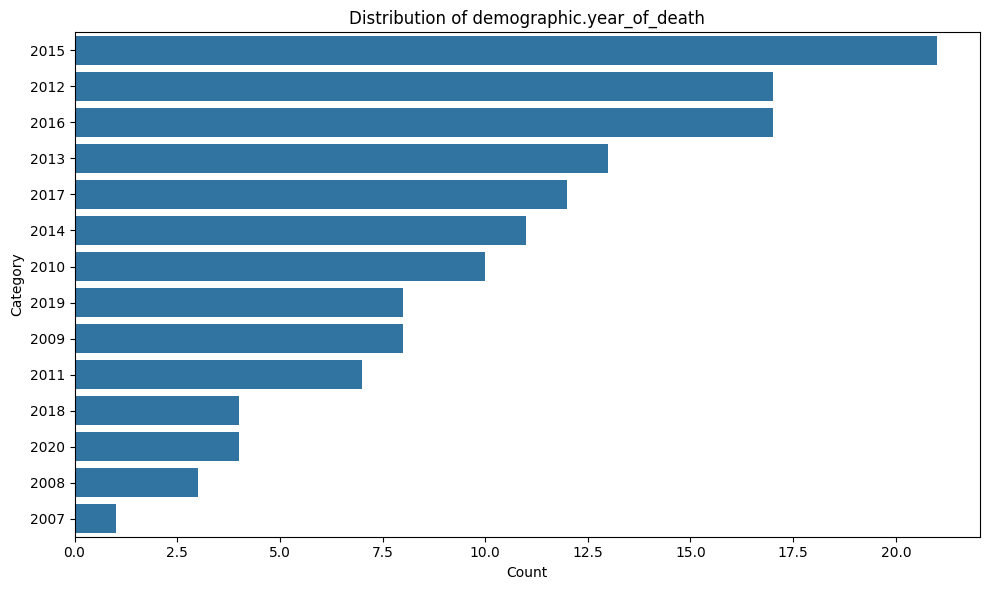

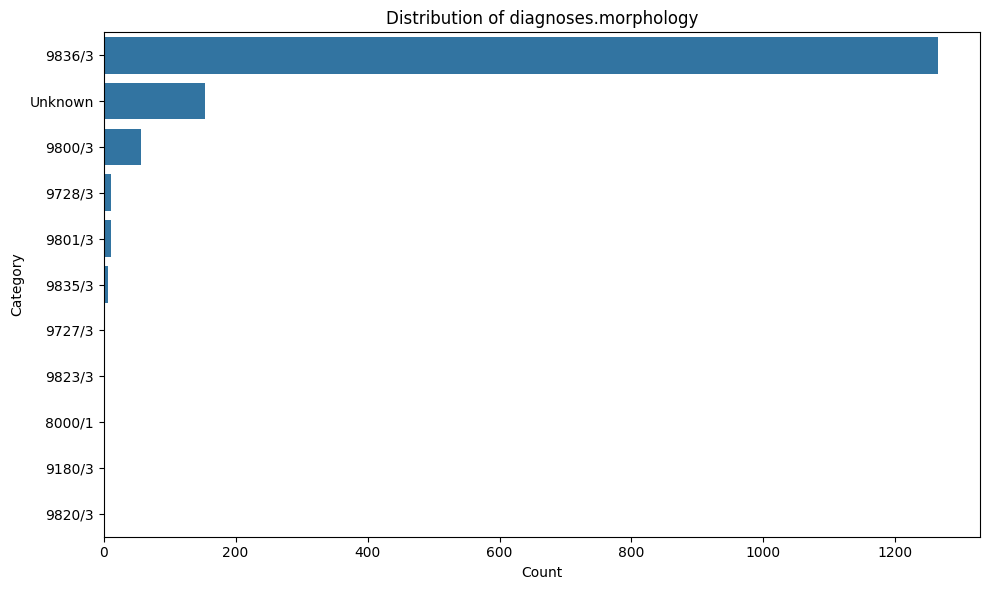

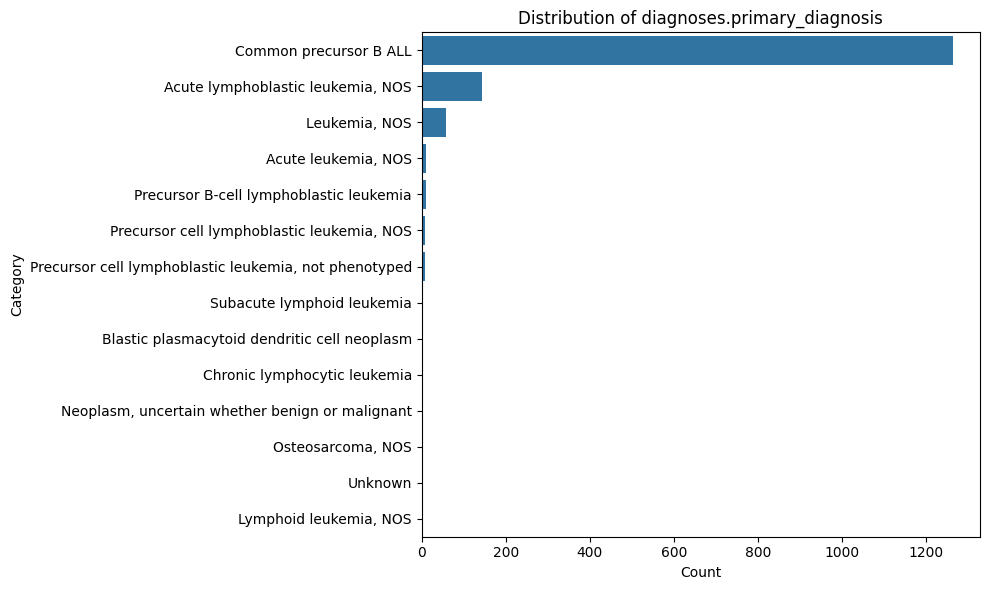

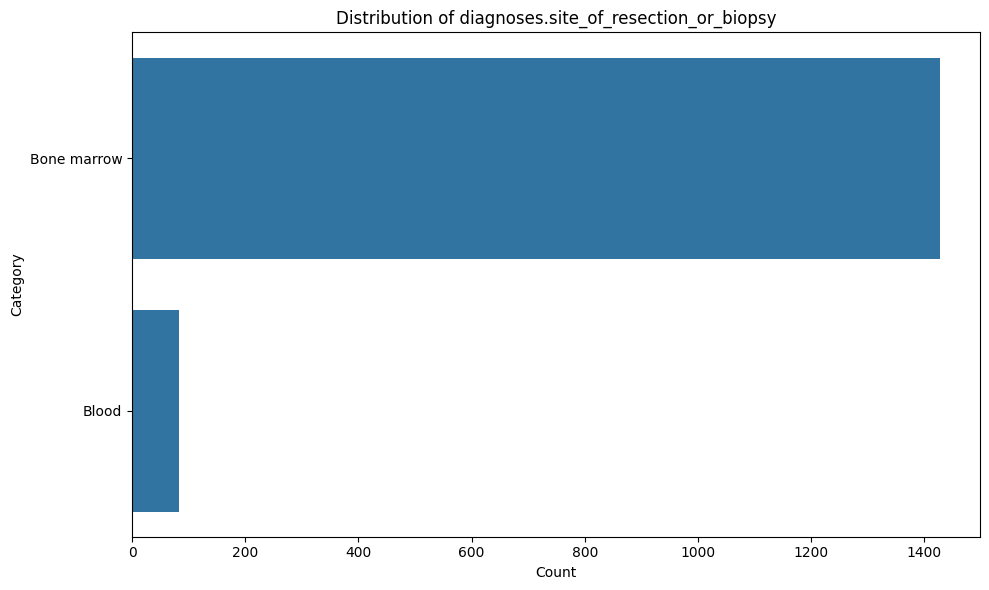

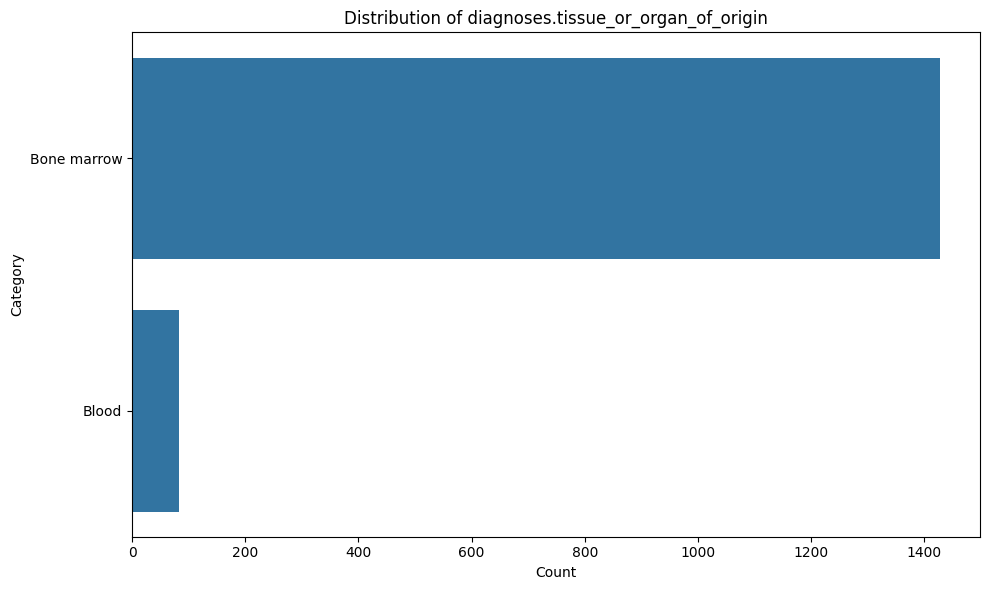

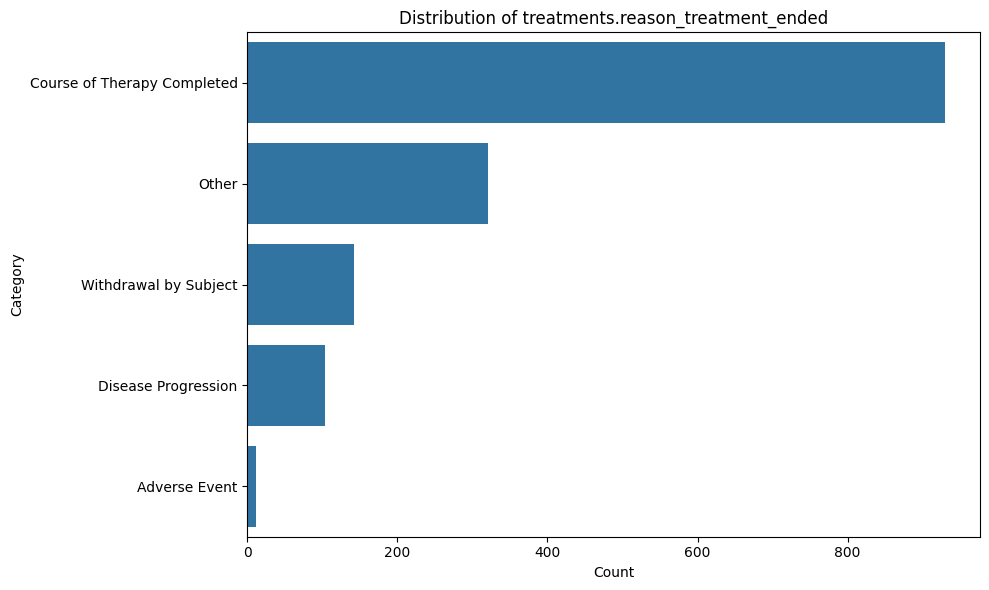


Column 'treatments.regimen_or_line_of_therapy' has 34 unique values (exceeds threshold 30). Printing value counts instead of plotting:
treatments.regimen_or_line_of_therapy
B-ALL Non-Down Syndrome  Induction Therapy                                                              176
Standard Induction - all patients in all groups                                                         138
SR-Low Group - LRS arm:  Standard Consolidation, Standard Interim Maintenance, Standard Delayed Inte     90
B-ALL Average Risk - Arm B Maintenance Therapy                                                           76
B-ALL Average Risk Post-Induction/Pre-Maintenance Therapy                                                74
SR-High Group - High arm:  Intensified Consolidation, Augmented Interim Maintenance, Augmented Delay     70
B-ALL Average Risk - Arm A Maintenance Therapy                                                           64
SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MTX+PEG; SDI; Maintenance 

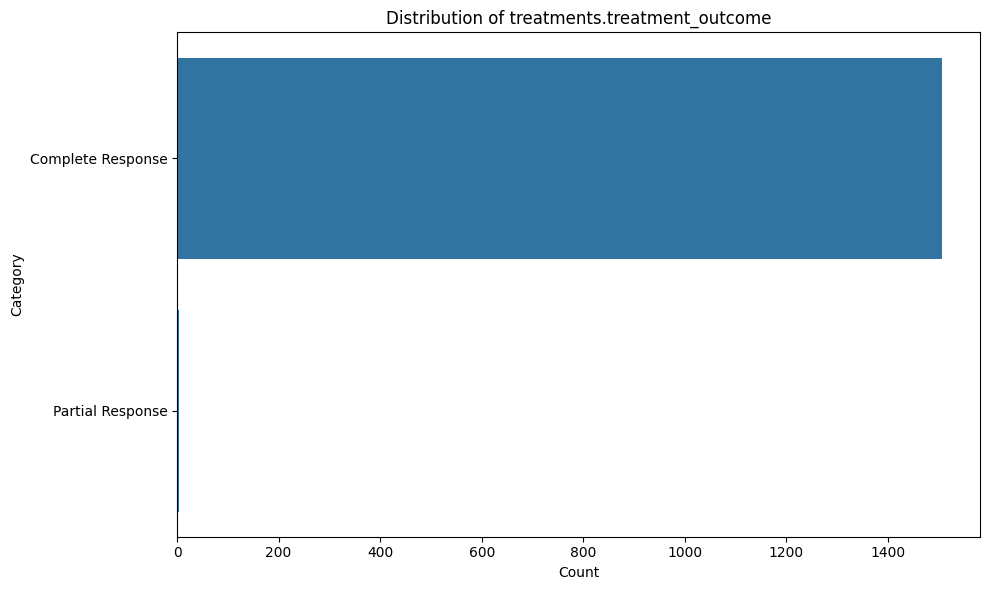

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'cases.case_id'
columns_to_plot = [col for col in df.select_dtypes(include='object').columns if col != 'cases.case_id']

# Set a threshold for the number of unique values to plot
# Columns with more than this threshold will have their value counts printed instead of a bar plot
UNIQUE_VALUE_THRESHOLD = 30

print("Generating category distribution plots and counts:")
for col in columns_to_plot:
    if df[col].nunique() <= UNIQUE_VALUE_THRESHOLD:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=col, data=df, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel('Category')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumn '{col}' has {df[col].nunique()} unique values (exceeds threshold {UNIQUE_VALUE_THRESHOLD}). Printing value counts instead of plotting:")
        print(df[col].value_counts())

In [ ]:
df['demographic.days_to_death'] = pd.to_numeric(df['demographic.days_to_death'], errors='coerce')

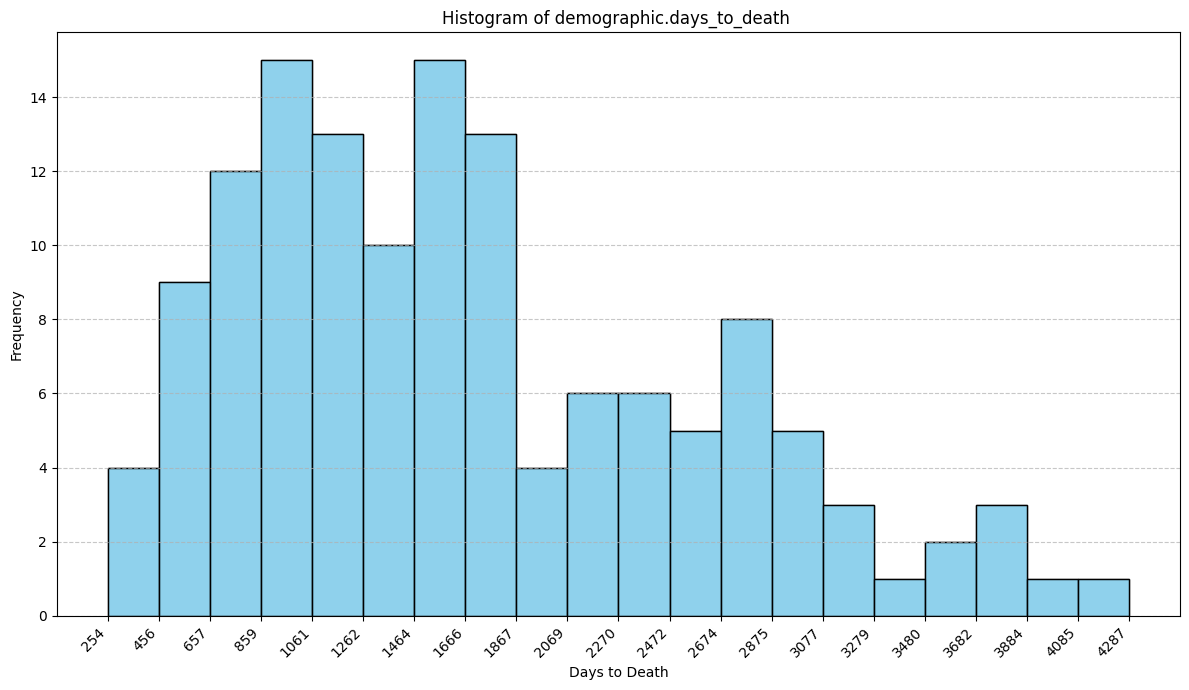

In [ ]:
# Create bins and plot a histogram of days_to_death

fig = plt.figure(figsize=(12, 7))
# Use plt.hist to get the bin edges, then pass them to sns.histplot
counts, bin_edges, _ = plt.hist(df['demographic.days_to_death'].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
sns.histplot(df['demographic.days_to_death'].dropna(), bins=bin_edges, kde=False, color='skyblue', edgecolor='black')
plt.title('Histogram of demographic.days_to_death ')
plt.xlabel('Days to Death')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(bin_edges, rotation=45, ha='right') # Set x-ticks to bin edges and rotate for readability
plt.tight_layout()
plt.show()

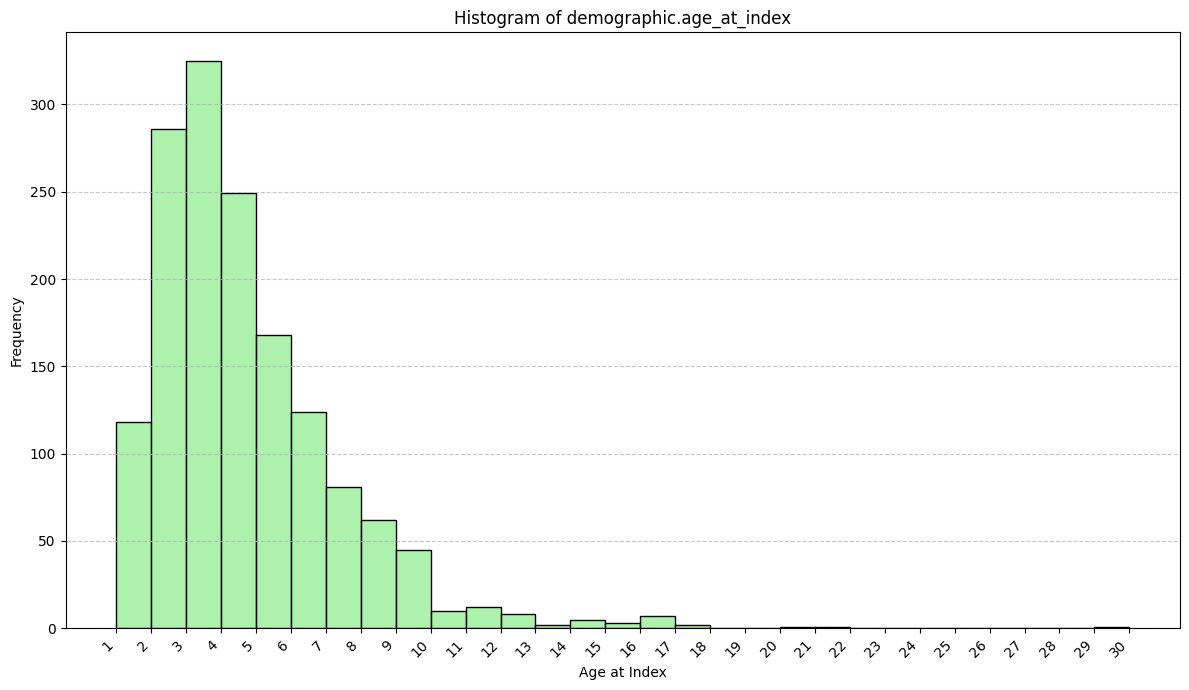

In [ ]:
# Create an age plot histogram to observe distribution of age of patients
fig_age = plt.figure(figsize=(12, 7))

# Determine min and max age to create whole number bins
min_age = int(df['demographic.age_at_index'].min())
max_age = int(df['demographic.age_at_index'].max())

# Create whole number bins
# We add 1 to max_age to ensure the last bin includes the max value
whole_number_bins = np.arange(min_age, max_age + 2, 1)

sns.histplot(df['demographic.age_at_index'].dropna(), bins=whole_number_bins, kde=False, color='lightgreen', edgecolor='black')
plt.title('Histogram of demographic.age_at_index')
plt.xlabel('Age at Index')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(whole_number_bins, rotation=45, ha='right') # Set x-ticks to whole number bin edges
plt.tight_layout()
plt.show()

To create a heatmap that includes all relevant columns with categorical data represented numerically, we will:

1.  Create a copy of the current DataFrame.
2.  Remove the `cases.case_id` column, as it's a unique identifier and not suitable for correlation.
3.  Convert the `demographic.year_of_death` column to a numeric type, as it represents a year.
4.  For all other `object` type columns, convert them to numerical categories using `.astype('category').cat.codes`. This maps each unique string value to an integer.

In [ ]:
# Create a copy of the DataFrame to avoid modifying the original 'df'
df_all_numeric = df.copy()

# Drop 'cases.case_id' as requested, if it exists
if 'cases.case_id' in df_all_numeric.columns:
    df_all_numeric = df_all_numeric.drop(columns=['cases.case_id'])

# Convert 'demographic.year_of_death' to numeric, coercing errors to NaN
# It was identified as 'object' but contains numerical data
df_all_numeric['demographic.year_of_death'] = pd.to_numeric(df_all_numeric['demographic.year_of_death'], errors='coerce')

# Identify remaining object columns (categorical) for integer encoding
categorical_cols_for_int_encoding = df_all_numeric.select_dtypes(include='object').columns

print(f"Categorical columns to be converted to integer codes: {list(categorical_cols_for_int_encoding)}")

# Convert identified categorical columns to integer codes
for col in categorical_cols_for_int_encoding:
    df_all_numeric[col] = df_all_numeric[col].astype('category').cat.codes

# Display the head and info of the new DataFrame to see the changes
display(df_all_numeric.head())
print(df_all_numeric.info())

Categorical columns to be converted to integer codes: ['cases.disease_type', 'demographic.country_of_residence_at_enrollment', 'demographic.ethnicity', 'demographic.gender', 'demographic.race', 'demographic.sex_at_birth', 'demographic.vital_status', 'diagnoses.morphology', 'diagnoses.primary_diagnosis', 'diagnoses.site_of_resection_or_biopsy', 'diagnoses.tissue_or_organ_of_origin', 'treatments.reason_treatment_ended', 'treatments.regimen_or_line_of_therapy', 'treatments.treatment_outcome']


,cases.disease_type,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.days_to_birth,demographic.days_to_death,demographic.ethnicity,demographic.gender,demographic.race,demographic.sex_at_birth,demographic.vital_status,...,diagnoses.primary_diagnosis,diagnoses.site_of_resection_or_biopsy,diagnoses.tissue_or_organ_of_origin,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.treatment_outcome
0,0,6,7,-2231,NaN,1,0,2,0,0,...,4,1,1,2012,810,1,6,1,7,0
1,0,6,7,-2492,1270.0,1,0,5,0,1,...,4,1,1,2010,821,1,5,1,30,0
2,0,2,7,-1026,NaN,1,0,5,0,2,...,4,1,1,2012,42,1,1,3,14,0
3,0,15,7,-5675,NaN,1,0,5,0,2,...,5,1,1,2007,862,2,5,1,2,0
4,0,2,7,-1040,NaN,0,0,5,0,0,...,4,1,1,2010,794,1,5,1,32,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cases.disease_type                              1510 non-null   int8   
 1   demographic.age_at_index                        1510 non-null   int64  
 2   demographic.country_of_residence_at_enrollment  1510 non-null   int8   
 3   demographic.days_to_birth                       1510 non-null   int64  
 4   demographic.days_to_death                       136 non-null    float64
 5   demographic.ethnicity                           1510 non-null   int8   
 6   demographic.gender                              1510 non-null   int8   
 7   demographic.race                                1510 non-null   int8   
 8   demographic.sex_at_birth                        1510 non-null   int8   
 9   demographic.vital_status                 

Now that all relevant columns in `df_all_numeric` are in a numerical format, we can generate a correlational heatmap. This heatmap will show the relationships between all features, including the original numerical columns and the newly encoded categorical ones.

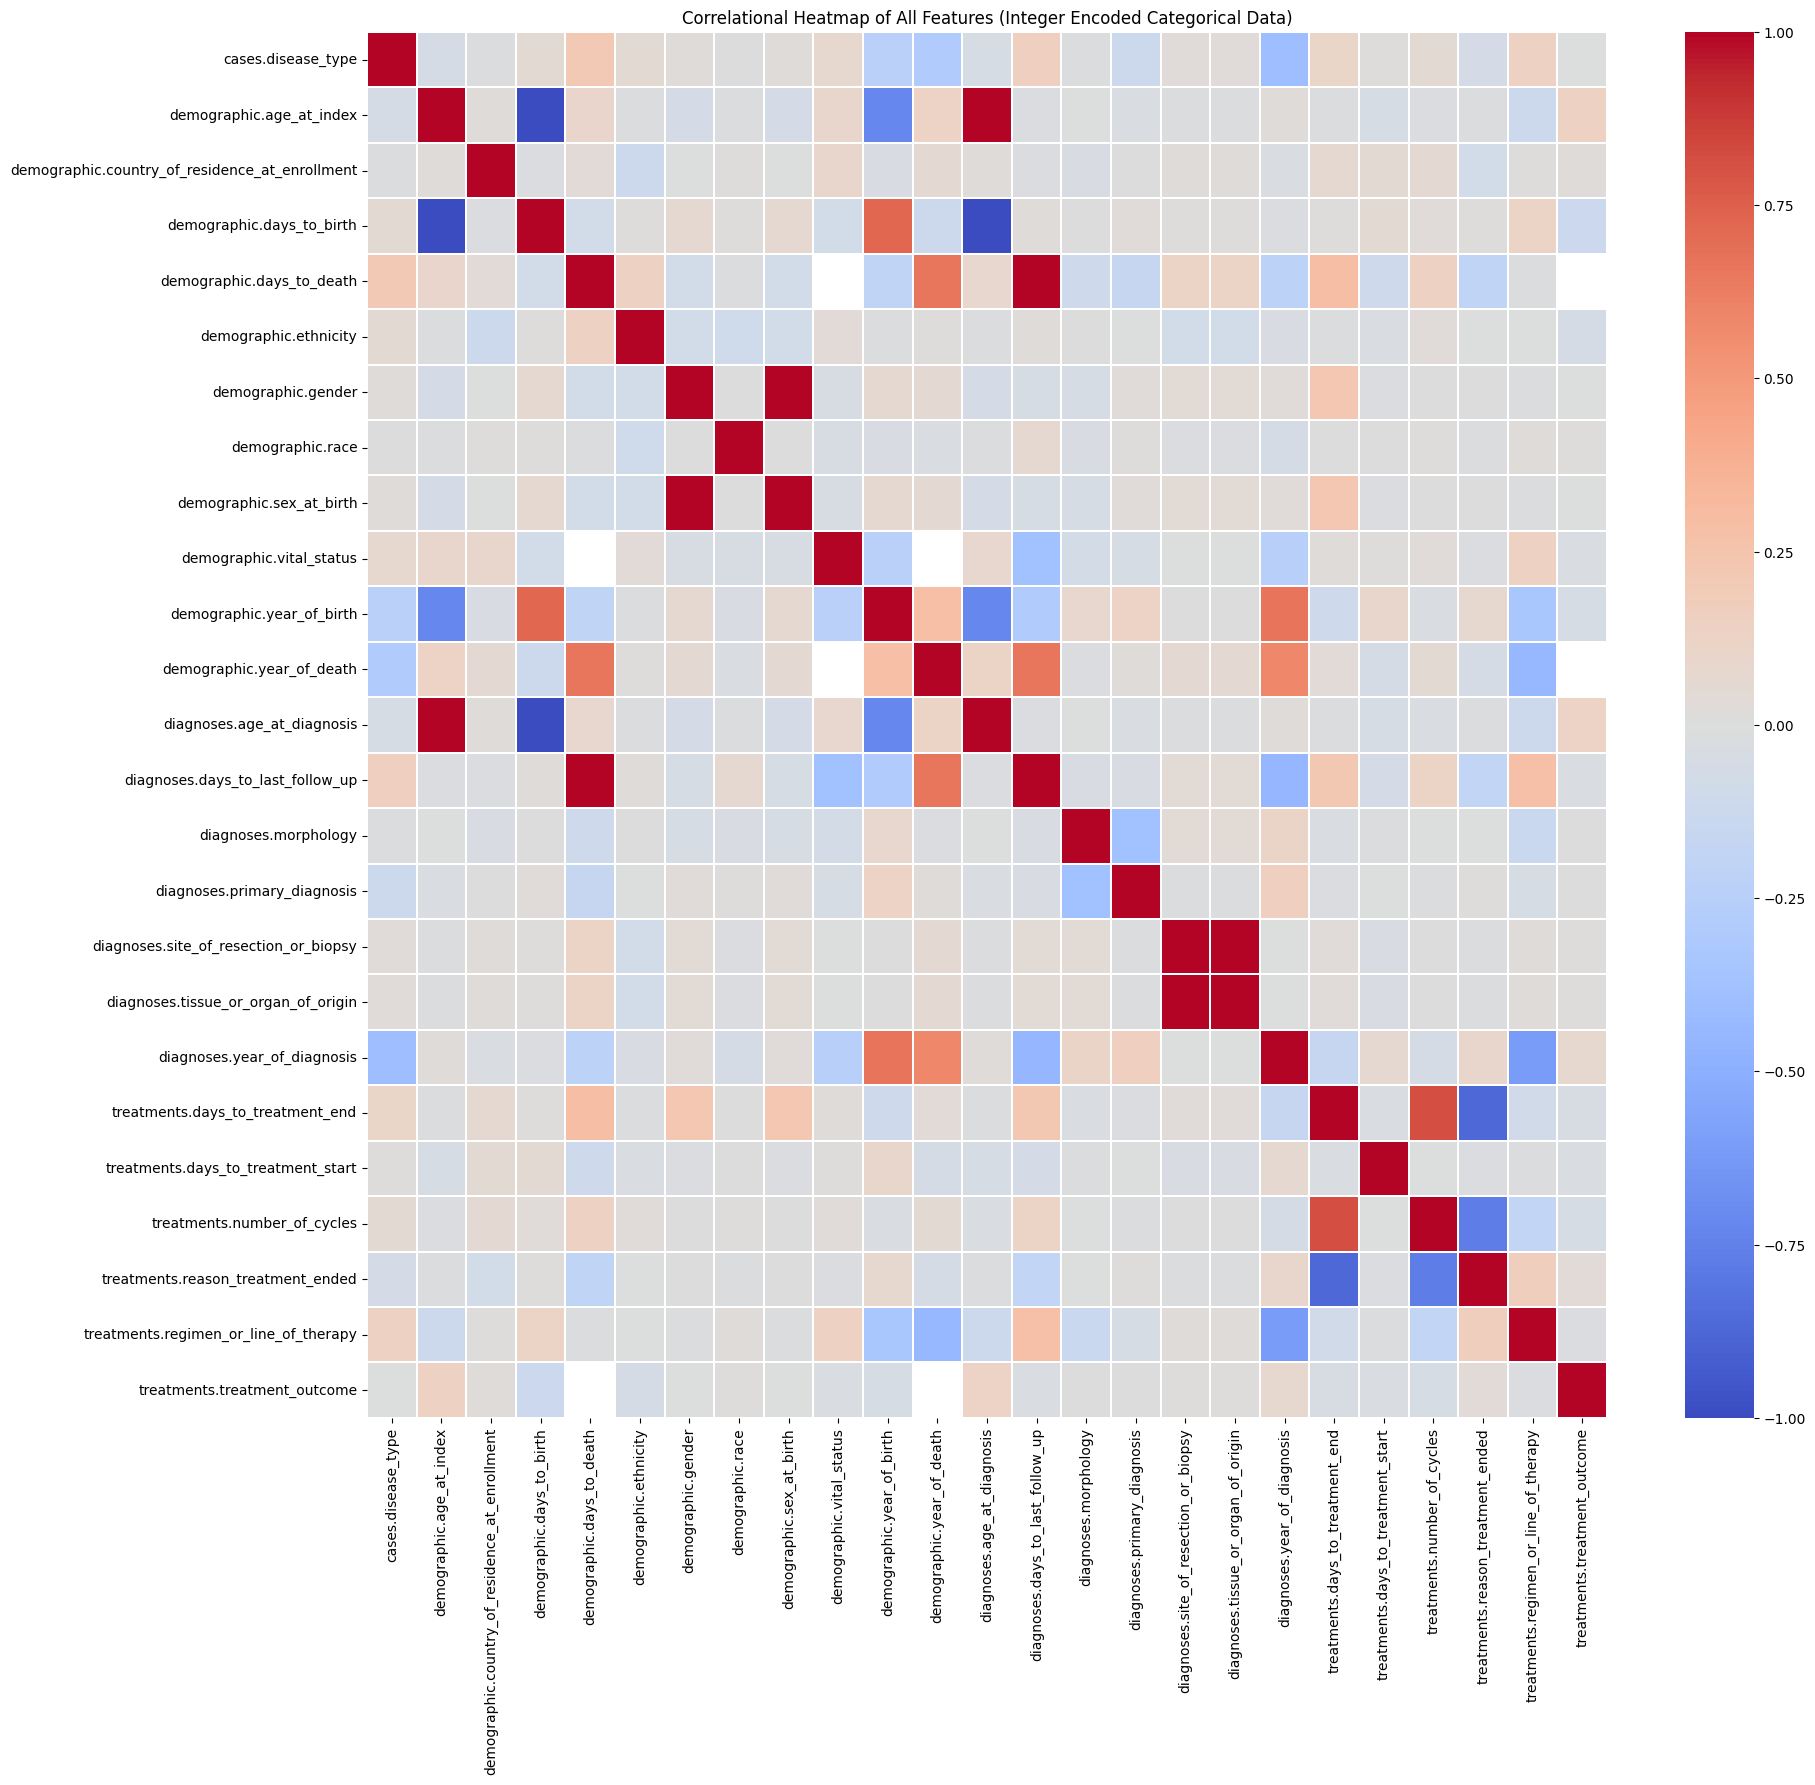

In [ ]:
# Calculate the correlation matrix for the fully numerical DataFrame
correlation_matrix_integer_encoded = df_all_numeric.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18)) # Adjust figure size for better visibility

# Draw the heatmap
sns.heatmap(correlation_matrix_integer_encoded, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.1)
plt.title('Correlational Heatmap of All Features (Integer Encoded Categorical Data)')
plt.show()

In [ ]:
threshold = 0.95
high_correlation_pairs = []

# Get the correlation matrix
corr_matrix = df_all_numeric.corr()

# Iterate through the upper triangle of the correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        correlation = corr_matrix.loc[col1, col2]

        if abs(correlation) >= threshold:
            high_correlation_pairs.append((col1, col2, correlation))

# Print the highly correlated pairs
if high_correlation_pairs:
    print(f"Column pairs with absolute correlation >= {threshold}:")
    for pair in high_correlation_pairs:
        print(f" {pair[0]} || {pair[1]}: {pair[2]:.4f}")
else:
    print(f"No column pairs found with absolute correlation >= {threshold}.")

Column pairs with absolute correlation >= 0.95:
 demographic.age_at_index || demographic.days_to_birth: -0.9940
 demographic.age_at_index || diagnoses.age_at_diagnosis: 0.9940
 demographic.days_to_birth || diagnoses.age_at_diagnosis: -1.0000
 demographic.days_to_death || diagnoses.days_to_last_follow_up: 1.0000
 demographic.gender || demographic.sex_at_birth: 1.0000
 diagnoses.site_of_resection_or_biopsy || diagnoses.tissue_or_organ_of_origin: 1.0000


In [ ]:
col = 'demographic.days_to_death'

def convert_days_to_years(x):
    # Case 1: blank / NaN
    if pd.isna(x):
        return "1"

    # Convert days → years
    years = round(x / 365)

    # Case 2: over 5 years
    if years >= 5:
        return "1"
    else:
        return "0"

    # Case 3: 0–5 years


df['death_years'] = df[col].apply(convert_days_to_years)
df['death_years'].value_counts()

,count
death_years,
1,1433
0,77


In [ ]:
#Remove single items of the highly correlated pairs
columns_to_drop_from_df = [
    'demographic.days_to_birth',
    'demographic.days_to_death',
    'demographic.sex_at_birth',
    'diagnoses.site_of_resection_or_biopsy'
]

df = df.drop(columns=columns_to_drop_from_df, errors='ignore')
df_all_numeric = df_all_numeric.drop(columns=columns_to_drop_from_df, errors='ignore')
print(f"Columns dropped from df: {columns_to_drop_from_df}")
df.info()

Columns dropped from df: ['demographic.days_to_birth', 'demographic.days_to_death', 'demographic.sex_at_birth', 'diagnoses.site_of_resection_or_biopsy']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cases.case_id                                   1510 non-null   object 
 1   cases.disease_type                              1510 non-null   object 
 2   demographic.age_at_index                        1510 non-null   int64  
 3   demographic.country_of_residence_at_enrollment  1510 non-null   object 
 4   demographic.ethnicity                           1510 non-null   object 
 5   demographic.gender                              1510 non-null   object 
 6   demographic.race                                1510 non-null   object 
 7   demographic.vital_status                  

#Identify Outliers

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

columns_with_outliers = {}

print("Identifying outliers using the IQR method:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    if not outliers.empty:
        columns_with_outliers[col] = len(outliers)

if columns_with_outliers:
    print("\nColumns with detected outliers:")
    for col, count in columns_with_outliers.items():
        print(f"- {col}: {count} outliers")
else:
    print("\nNo significant outliers detected in numerical columns using the IQR method.")

Identifying outliers using the IQR method:

Columns with detected outliers:
- demographic.age_at_index: 52 outliers
- demographic.year_of_birth: 25 outliers
- diagnoses.age_at_diagnosis: 48 outliers
- diagnoses.days_to_last_follow_up: 20 outliers
- treatments.days_to_treatment_start: 12 outliers


In [ ]:
print("\nDisplaying rows with outliers:")

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter the DataFrame to get rows with outliers for the current column
    outlier_rows = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outlier_rows.empty:
        print(f"\nOutliers in column: '{col}' ({len(outlier_rows)} rows):")
        display(outlier_rows[['cases.case_id', col]])
    else:
        print(f"\nNo outliers found for column: '{col}' after re-evaluation.")


Displaying rows with outliers:

Outliers in column: 'demographic.age_at_index' (52 rows):


,cases.case_id,demographic.age_at_index
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,15
45,0926793b-88d9-4339-b218-3c68b3204a9c,12
94,118f62e8-7ffb-40bf-a2ba-4a8c4ef622af,16
106,13527b49-1624-44c4-a93d-f92ae3948b60,15
108,13b3d0e5-23a9-4e15-8e0e-4974b62a5a36,11
125,16924a9d-2d56-4823-9c01-616998b73b8e,16
131,18440156-b850-4756-952c-039db9279fd7,10
132,1875c280-4d9a-4e21-827d-2b2d5e0a9af8,11
186,20017036-c6a4-46f1-8b3d-a7d804e06ca0,12
205,23185e6d-0157-4e96-ab3e-15f155a4be4a,14



Outliers in column: 'demographic.year_of_birth' (25 rows):


,cases.case_id,demographic.year_of_birth
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,1992
94,118f62e8-7ffb-40bf-a2ba-4a8c4ef622af,1992
106,13527b49-1624-44c4-a93d-f92ae3948b60,1988
108,13b3d0e5-23a9-4e15-8e0e-4974b62a5a36,1994
125,16924a9d-2d56-4823-9c01-616998b73b8e,1994
186,20017036-c6a4-46f1-8b3d-a7d804e06ca0,1994
205,23185e6d-0157-4e96-ab3e-15f155a4be4a,1994
208,236359d7-0f9e-4851-ae16-04829aa3d667,1992
344,3f345a8e-9733-446b-bdbd-c6e5f537487b,1983
443,5090b67b-077b-43fb-9d4b-88b99cf51a31,1992



Outliers in column: 'diagnoses.age_at_diagnosis' (48 rows):


...


Outliers in column: 'diagnoses.days_to_last_follow_up' (20 rows):


,cases.case_id,diagnoses.days_to_last_follow_up
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,439.0
180,1f3aff00-6c0d-4c23-948b-45ac2edb1406,621.0
244,2ae0f7d1-201b-475d-bc33-fb119815138e,553.0
271,31ae5149-0525-4ffc-ba7e-9f8c759547bb,698.0
288,33fe115b-3498-4039-9367-15465422ff99,291.0
391,48673569-e66f-4b01-8c02-1f920d2bac0d,751.0
464,53ea8d80-afcd-457e-9307-dfe4bbb4f359,638.0
621,6d60652e-32ed-403e-89c4-201608ef005a,545.0
716,7a4bac15-25fe-428b-9552-7d2b52303b62,295.0
822,8c5b554f-40c2-4a39-af50-c7dd94c47ad2,611.0



No outliers found for column: 'diagnoses.year_of_diagnosis' after re-evaluation.

No outliers found for column: 'treatments.days_to_treatment_end' after re-evaluation.

Outliers in column: 'treatments.days_to_treatment_start' (12 rows):


,cases.case_id,treatments.days_to_treatment_start
246,2b5a7cae-0158-4efb-b739-75f9a3cdd951,7
259,2ecc654c-7c34-402e-86f5-4781aeac3682,7
305,371aadc0-87f4-47bd-9b9e-dd1d40838c51,7
425,4e4f1c40-4fe4-4396-8b38-03fd905e8334,8
472,557eeb05-995d-476b-8463-093da93caf0a,8
490,590e60b7-ef2d-4e9f-8680-982f82c8c938,7
672,73f24361-d911-4d1e-afbd-0b915a5c1c21,7
858,90898c49-b01b-4899-b49a-5a66eca75519,10
1136,c3fcc2b9-d6d1-423b-8464-9d3247c23ff7,7
1302,deebb383-c6df-4a82-a90d-e8a3e984ba47,32



No outliers found for column: 'treatments.number_of_cycles' after re-evaluation.


Upon inspection of the outliers. All appear clinically relevant and don't appear to be data entry errors. The patient of age 29, while quite a lot older than other patients, the other age-related columns match, suggesting it is genuine.

Let's impute missing values for reason_treatment_ended.

In [ ]:
missing_reason_treatment_ended = df[df['treatments.reason_treatment_ended'].isnull()]
display(missing_reason_treatment_ended)

,cases.case_id,cases.disease_type,demographic.age_at_index,demographic.country_of_residence_at_enrollment,demographic.ethnicity,demographic.gender,demographic.race,demographic.vital_status,demographic.year_of_birth,demographic.year_of_death,...,diagnoses.primary_diagnosis,diagnoses.tissue_or_organ_of_origin,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.reason_treatment_ended,treatments.regimen_or_line_of_therapy,treatments.treatment_outcome,death_years
1087,bac85f1f-e16f-4fff-a859-a87d9ec53ddc,Acute Lymphoblastic Leukemia,2,United States,not hispanic or latino,male,white,Alive,2010,NaN,...,Common precursor B ALL,Bone marrow,2012,35,4,1,NaN,Arm A � HR Patients,Complete Response,1


In [ ]:
# Define the conditions for the subgroup
condition = (
    (df['demographic.gender'] == 'male') &
    (df['demographic.age_at_index'] < 5) &
    (df['demographic.country_of_residence_at_enrollment'] == 'United States')
)

# Find the most common reason_treatment_ended for this subgroup (excluding NaNs)
most_common_reason = df[condition]['treatments.reason_treatment_ended'].mode()[0]

print(f"The most common 'treatments.reason_treatment_ended' for the specified subgroup is: '{most_common_reason}'")

# Impute the missing values in 'treatments.reason_treatment_ended' for the identified rows
df.loc[condition & df['treatments.reason_treatment_ended'].isnull(), 'treatments.reason_treatment_ended'] = most_common_reason

# Verify the imputation
print("\nVerifying imputation:")
missing_after_imputation = df[df['treatments.reason_treatment_ended'].isnull()]

if missing_after_imputation.empty:
    print("All missing values in 'treatments.reason_treatment_ended' have been imputed.")
else:
    print(f"{len(missing_after_imputation)} missing values remaining in 'treatments.reason_treatment_ended':")
    display(missing_after_imputation[['cases.case_id', 'demographic.gender', 'demographic.age_at_index', 'demographic.country_of_residence_at_enrollment', 'treatments.reason_treatment_ended']])

The most common 'treatments.reason_treatment_ended' for the specified subgroup is: 'Course of Therapy Completed'

Verifying imputation:
All missing values in 'treatments.reason_treatment_ended' have been imputed.


#Separate DF for Bayesian Network binning

In [ ]:
df_bayesian = df.copy()

In [ ]:
df_bayesian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cases.case_id                                   1510 non-null   object 
 1   cases.disease_type                              1510 non-null   object 
 2   demographic.age_at_index                        1510 non-null   int64  
 3   demographic.country_of_residence_at_enrollment  1510 non-null   object 
 4   demographic.ethnicity                           1510 non-null   object 
 5   demographic.gender                              1510 non-null   object 
 6   demographic.race                                1510 non-null   object 
 7   demographic.vital_status                        1510 non-null   object 
 8   demographic.year_of_birth                       1510 non-null   int64  
 9   demographic.year_of_death                

In [ ]:
#create age bins for bayesian usage
bins = [-1, 2, 5, 8, 11, 14, 17, float('inf')]
labels = ["<=2", "3-5", "6-8", "9-11", "12-14", "15-17", "18+"]

df_bayesian['demographic.age_at_index'] = pd.cut(df_bayesian['demographic.age_at_index'], bins=bins, labels=labels)
df_bayesian['demographic.age_at_index'].value_counts()

,count
demographic.age_at_index,
3-5,742
<=2,404
6-8,267
9-11,67
12-14,15
15-17,12
18+,3


In [ ]:
#create age_diagnosis bins for bayesian usage
df_bayesian['age_diag_years'] = (df_bayesian['diagnoses.age_at_diagnosis'] / 365).round()
bins = [-1, 2, 5, 8, 11, 14, 17, float('inf')]
labels = ["<=2", "3-5", "6-8", "9-11", "12-14", "15-17", "18+"]

df_bayesian['age_diag_years'] = pd.cut(df_bayesian['age_diag_years'], bins=bins, labels=labels)
df_bayesian['age_diag_years'].value_counts()

,count
age_diag_years,
3-5,830
6-8,314
<=2,241
9-11,90
12-14,19
15-17,12
18+,4


In [ ]:
#create days treatment start bins for bayesian usage
df_bayesian['days_treatment_start'] = df_bayesian['treatments.days_to_treatment_start']
bins = [-1, 1, 2, 3, 4, 5, 6, float('inf')]
labels = ["0", "1", "2", "3", "4", "5", "6+"]

df_bayesian['days_treatment_start'] = pd.cut(df_bayesian['days_treatment_start'], bins=bins, labels=labels)
df_bayesian['days_treatment_start'].value_counts()

,count
days_treatment_start,
0,646
1,362
2,221
3,173
4,71
5,25
6+,12


In [ ]:
#initialize for days treatment end bins for bayesian usage
col = 'treatments.days_to_treatment_end'

# Create the bins
bins = pd.cut(df_bayesian[col], bins=6)

# Extract the Interval objects
intervals = bins.cat.categories
intervals


IntervalIndex([  (24.718, 239.667],  (239.667, 453.333],    (453.333, 667.0],
                  (667.0, 880.667], (880.667, 1094.333],  (1094.333, 1308.0]],
              dtype='interval[float64, right]')

In [ ]:
labels = [f"{int(i.left)}-{int(i.right)-1}" for i in intervals]
labels

['24-238', '239-452', '453-666', '667-879', '880-1093', '1094-1307']

In [ ]:
#create days treatment end bins for bayesian usage
df_bayesian['days_treatment_end'] = pd.cut(
    df_bayesian[col],
    bins=6,
    labels=labels
)
df_bayesian['days_treatment_end'].value_counts()

,count
days_treatment_end,
1094-1307,495
667-879,416
24-238,392
239-452,85
880-1093,75
453-666,47


In [ ]:
#initialize for days last follow up for bayesian usage
col = 'diagnoses.days_to_last_follow_up'

# Create the bins
bins = pd.cut(df_bayesian[col], bins=6)

# Extract the Interval objects
intervals = bins.cat.categories
intervals

IntervalIndex([ (248.749, 1129.167], (1129.167, 2004.333],
                 (2004.333, 2879.5],   (2879.5, 3754.667],
               (3754.667, 4629.833],   (4629.833, 5505.0]],
              dtype='interval[float64, right]')

In [ ]:
labels = [f"{int(i.left)}-{int(i.right)-1}" for i in intervals]
labels

['248-1128', '1129-2003', '2004-2878', '2879-3753', '3754-4628', '4629-5504']

In [ ]:
#create days last follow up end bins for bayesian usage
df_bayesian['days_last_follow_up'] = pd.cut(
    df_bayesian[col],
    bins=6,
    labels=labels
)
df_bayesian['days_last_follow_up'].value_counts()

,count
days_last_follow_up,
2879-3753,549
2004-2878,479
3754-4628,322
1129-2003,97
248-1128,47
4629-5504,16


In [ ]:
df_bayesian['treatments.number_of_cycles'] = (
    df_bayesian['treatments.number_of_cycles'].astype('category')
)
df_bayesian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   cases.case_id                                   1510 non-null   object  
 1   cases.disease_type                              1510 non-null   object  
 2   demographic.age_at_index                        1510 non-null   category
 3   demographic.country_of_residence_at_enrollment  1510 non-null   object  
 4   demographic.ethnicity                           1510 non-null   object  
 5   demographic.gender                              1510 non-null   object  
 6   demographic.race                                1510 non-null   object  
 7   demographic.vital_status                        1510 non-null   object  
 8   demographic.year_of_birth                       1510 non-null   int64   
 9   demographic.year_of_death     

In [ ]:
#drop continuous columns
columns_to_drop_from_df_bayesian = [
    'demographic.year_of_birth',
    'demographic.year_of_death',
    'diagnoses.age_at_diagnosis',
    'diagnoses.year_of_diagnosis',
    'treatments.days_to_treatment_start',
    'treatments.days_to_treatment_end',
    'diagnoses.days_to_last_follow_up'
]
df_bayesian = df_bayesian.drop(columns=columns_to_drop_from_df_bayesian, errors='ignore')
df_bayesian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 20 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   cases.case_id                                   1510 non-null   object  
 1   cases.disease_type                              1510 non-null   object  
 2   demographic.age_at_index                        1510 non-null   category
 3   demographic.country_of_residence_at_enrollment  1510 non-null   object  
 4   demographic.ethnicity                           1510 non-null   object  
 5   demographic.gender                              1510 non-null   object  
 6   demographic.race                                1510 non-null   object  
 7   demographic.vital_status                        1510 non-null   object  
 8   diagnoses.morphology                            1510 non-null   object  
 9   diagnoses.primary_diagnosis   

In [ ]:
for col in ['demographic.country_of_residence_at_enrollment', 'demographic.ethnicity', 'demographic.gender', 'demographic.race', 'demographic.vital_status']:
    df_bayesian[col] = df_bayesian[col].astype('category')

print("Converted selected object columns to category dtype in df_bayesian.")
df_bayesian.info()

Converted selected object columns to category dtype in df_bayesian.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 20 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   cases.case_id                                   1510 non-null   object  
 1   cases.disease_type                              1510 non-null   object  
 2   demographic.age_at_index                        1510 non-null   category
 3   demographic.country_of_residence_at_enrollment  1510 non-null   category
 4   demographic.ethnicity                           1510 non-null   category
 5   demographic.gender                              1510 non-null   category
 6   demographic.race                                1510 non-null   category
 7   demographic.vital_status                        1510 non-null   category
 8   diagnoses.morphology                    

Now that the relevant columns in `df_bayesian` are categorical, I will define the Bayesian Network using these demographic factors and fit the model.

#One-Hot encode categorical Values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cases.case_id                                   1510 non-null   object 
 1   cases.disease_type                              1510 non-null   object 
 2   demographic.age_at_index                        1510 non-null   int64  
 3   demographic.country_of_residence_at_enrollment  1510 non-null   object 
 4   demographic.ethnicity                           1510 non-null   object 
 5   demographic.gender                              1510 non-null   object 
 6   demographic.race                                1510 non-null   object 
 7   demographic.vital_status                        1510 non-null   object 
 8   demographic.year_of_birth                       1510 non-null   int64  
 9   demographic.year_of_death                

In [ ]:
# Create a copy of the DataFrame for one-hot encoding
df_one_hot = df.copy()

# Columns for one-hot encoding
one_hot_cols = [
    'demographic.country_of_residence_at_enrollment',
    'demographic.ethnicity',
    'demographic.race',
    'diagnoses.morphology',
    'diagnoses.tissue_or_organ_of_origin',
    'treatments.reason_treatment_ended',
    'treatments.regimen_or_line_of_therapy'
]

# Columns for binary conversion
binary_cols_mapping = {
    'demographic.gender': {'male': 1, 'female': 0},
    'treatments.treatment_outcome': {'Complete Response': 1, 'Partial Response': 0},
    'demographic.vital_status': {'Dead': 2, 'Alive': 1, 'Unknown': 0}
}

# Apply binary conversion
for col, mapping in binary_cols_mapping.items():
    df_one_hot[col] = df_one_hot[col].map(mapping)

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply one-hot encoding
encoded_features = encoder.fit_transform(df_one_hot[one_hot_cols])

# Create a DataFrame from the encoded features with appropriate column names
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(one_hot_cols), index=df_one_hot.index)

# Drop the original categorical columns and concatenate the new encoded columns
df_one_hot = df_one_hot.drop(columns=one_hot_cols)
df_one_hot = pd.concat([df_one_hot, encoded_df], axis=1)

# Display the head of the new DataFrame
print("Head of the DataFrame after one-hot encoding and binary conversion:")
display(df_one_hot.head())

# Display the info of the new DataFrame to show column types and counts
print("\nInfo of the DataFrame after one-hot encoding and binary conversion:")
df_one_hot.info()

Head of the DataFrame after one-hot encoding and binary conversion:


,cases.case_id,cases.disease_type,demographic.age_at_index,demographic.gender,demographic.vital_status,demographic.year_of_birth,demographic.year_of_death,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up,diagnoses.primary_diagnosis,...,"treatments.regimen_or_line_of_therapy_SR-Average Risk - IA arm: Intensified Consolidation, Augmented Interim Maintenance, Augmented Delay",treatments.regimen_or_line_of_therapy_SR-Avg Group - IS-IV arm: IC; SIM+IV-MTX; SDI; Maintenance,treatments.regimen_or_line_of_therapy_SR-Avg Group - SS-IV arm: SC; SIM+IV-MTX; SDI; Maintenance,"treatments.regimen_or_line_of_therapy_SR-High Group - High arm: Intensified Consolidation, Augmented Interim Maintenance, Augmented Delay",treatments.regimen_or_line_of_therapy_SR-High Group - High arm: IC; AIM 1; ADI 1; AIM 2; ADI 2; Maintenance,"treatments.regimen_or_line_of_therapy_SR-Low Group - LRAsp arm: Standard Consolidation + 2 doses of PEG, Standard Interim Maintenance + 2",treatments.regimen_or_line_of_therapy_SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MTX+PEG; SDI; Maintenance,"treatments.regimen_or_line_of_therapy_SR-Low Group - LRS arm: Standard Consolidation, Standard Interim Maintenance, Standard Delayed Inte",treatments.regimen_or_line_of_therapy_SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI; Maintenance,treatments.regimen_or_line_of_therapy_Standard Induction - all patients in all groups
0,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,6,0,1,2006,NaN,2231,2976.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,6,0,2,2003,2013,2492,1270.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,2,0,0,2009,NaN,1026,439.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,15,0,0,1992,NaN,5675,2077.0,"Leukemia, NOS",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,2,0,1,2007,NaN,1040,3625.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



Info of the DataFrame after one-hot encoding and binary conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 85 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   cases.case_id                                                                                                                               1510 non-null   object 
 1   cases.disease_type                                                                                                                          1510 non-null   object 
 2   demographic.age_at_index                                                                                                                    151

In [ ]:
# Create a copy of the DataFrame to add standardized columns
df_with_standardized_cols = df_one_hot.copy()

# Ensure 'demographic.year_of_death' is numeric in the copied DataFrame for standardization
df_with_standardized_cols['demographic.year_of_death'] = pd.to_numeric(df_with_standardized_cols['demographic.year_of_death'], errors='coerce')

# Columns to standardize
columns_to_standardize = [
    'demographic.age_at_index',
    'diagnoses.age_at_diagnosis',
    'demographic.year_of_death'
]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the selected columns and replace them in the new DataFrame
df_with_standardized_cols[columns_to_standardize] = scaler.fit_transform(df_with_standardized_cols[columns_to_standardize])

# Display the first few rows of the DataFrame with standardized columns
print("Head of the DataFrame with standardized columns:")
display(df_with_standardized_cols.head())

Head of the DataFrame with standardized columns:


,cases.case_id,cases.disease_type,demographic.age_at_index,demographic.gender,demographic.vital_status,demographic.year_of_birth,demographic.year_of_death,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up,diagnoses.primary_diagnosis,...,"treatments.regimen_or_line_of_therapy_SR-Average Risk - IA arm: Intensified Consolidation, Augmented Interim Maintenance, Augmented Delay",treatments.regimen_or_line_of_therapy_SR-Avg Group - IS-IV arm: IC; SIM+IV-MTX; SDI; Maintenance,treatments.regimen_or_line_of_therapy_SR-Avg Group - SS-IV arm: SC; SIM+IV-MTX; SDI; Maintenance,"treatments.regimen_or_line_of_therapy_SR-High Group - High arm: Intensified Consolidation, Augmented Interim Maintenance, Augmented Delay",treatments.regimen_or_line_of_therapy_SR-High Group - High arm: IC; AIM 1; ADI 1; AIM 2; ADI 2; Maintenance,"treatments.regimen_or_line_of_therapy_SR-Low Group - LRAsp arm: Standard Consolidation + 2 doses of PEG, Standard Interim Maintenance + 2",treatments.regimen_or_line_of_therapy_SR-Low Group - LRAsp-IV arm: SC+PEG; SIM+IV-MTX+PEG; SDI; Maintenance,"treatments.regimen_or_line_of_therapy_SR-Low Group - LRS arm: Standard Consolidation, Standard Interim Maintenance, Standard Delayed Inte",treatments.regimen_or_line_of_therapy_SR-Low Group - LRS-IV arm: SC; SIM+IV-MTX; SDI; Maintenance,treatments.regimen_or_line_of_therapy_Standard Induction - all patients in all groups
0,00318ddd-89bc-4a35-af79-5ab407fbd278,Acute Lymphoblastic Leukemia,0.654442,0,1,2006,NaN,0.512423,2976.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0079b2ff-6c93-47b0-95cb-4cc9b8915e12,Acute Lymphoblastic Leukemia,0.654442,0,2,2003,-0.322941,0.779226,1270.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,00a65c23-8fa2-46b1-8cff-78652fa8e4ab,Acute Lymphoblastic Leukemia,-0.830468,0,0,2009,NaN,-0.719368,439.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00d973d4-9eb1-4e77-a02b-ce4d954f9624,Acute Lymphoblastic Leukemia,3.995490,0,0,1992,NaN,4.032995,2077.0,"Leukemia, NOS",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,00ef4e4f-a44b-467c-923c-3c001abdaa5d,Acute Lymphoblastic Leukemia,-0.830468,0,1,2007,NaN,-0.705057,3625.0,Common precursor B ALL,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
# Identify all 'demographic' columns in df_one_hot
demographic_cols = [col for col in df_one_hot.columns if col.startswith('demographic.')]

# Add 'diagnoses.primary_diagnosis' to the list of desired columns
demographic_plus_diagnosis_cols = demographic_cols + ['diagnoses.primary_diagnosis']

# Create df_demographic by selecting these columns from df_one_hot
df_demographic = df_one_hot[demographic_plus_diagnosis_cols].copy()

print("Head of the new df_demographic DataFrame:")
display(df_demographic.head())

print("\nInfo of the new df_demographic DataFrame:")
df_demographic.info()

Head of the new df_demographic DataFrame:


,demographic.age_at_index,demographic.gender,demographic.vital_status,demographic.year_of_birth,demographic.year_of_death,demographic.country_of_residence_at_enrollment_Albania,demographic.country_of_residence_at_enrollment_Australia,demographic.country_of_residence_at_enrollment_Bahamas,demographic.country_of_residence_at_enrollment_Canada,demographic.country_of_residence_at_enrollment_Dominican Republic,...,demographic.ethnicity_hispanic or latino,demographic.ethnicity_not hispanic or latino,demographic.ethnicity_unknown,demographic.race_american indian or alaska native,demographic.race_asian,demographic.race_black or african american,demographic.race_native hawaiian or other pacific islander,demographic.race_unknown,demographic.race_white,diagnoses.primary_diagnosis
0,6,0,1,2006,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Common precursor B ALL
1,6,0,2,2003,2013,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Common precursor B ALL
2,2,0,0,2009,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Common precursor B ALL
3,15,0,0,1992,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"Leukemia, NOS"
4,2,0,1,2007,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Common precursor B ALL



Info of the new df_demographic DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 23 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   demographic.age_at_index                                           1510 non-null   int64  
 1   demographic.gender                                                 1510 non-null   int64  
 2   demographic.vital_status                                           1510 non-null   int64  
 3   demographic.year_of_birth                                          1510 non-null   int64  
 4   demographic.year_of_death                                          136 non-null    object 
 5   demographic.country_of_residence_at_enrollment_Albania             1510 non-null   float64
 6   demographic.country_of_residence_at_enrollment_Australia           1510 non-n

In [ ]:
# Create df_q1 by copying df_demographic
df_q1 = df_demographic.copy()

# Drop 'diagnoses.primary_diagnosis' from df_q1
df_q1 = df_q1.drop(columns=['diagnoses.primary_diagnosis'])

print("Head of the new df_q1 DataFrame (without diagnoses.primary_diagnosis):")
display(df_q1.head())

print("\nInfo of the new df_q1 DataFrame:")
df_q1.info()

Head of the new df_q1 DataFrame (without diagnoses.primary_diagnosis):


,demographic.age_at_index,demographic.gender,demographic.vital_status,demographic.year_of_birth,demographic.year_of_death,demographic.country_of_residence_at_enrollment_Albania,demographic.country_of_residence_at_enrollment_Australia,demographic.country_of_residence_at_enrollment_Bahamas,demographic.country_of_residence_at_enrollment_Canada,demographic.country_of_residence_at_enrollment_Dominican Republic,...,demographic.country_of_residence_at_enrollment_United States,demographic.ethnicity_hispanic or latino,demographic.ethnicity_not hispanic or latino,demographic.ethnicity_unknown,demographic.race_american indian or alaska native,demographic.race_asian,demographic.race_black or african american,demographic.race_native hawaiian or other pacific islander,demographic.race_unknown,demographic.race_white
0,6,0,1,2006,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,6,0,2,2003,2013,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,0,0,2009,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,15,0,0,1992,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2,0,1,2007,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Info of the new df_q1 DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 22 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   demographic.age_at_index                                           1510 non-null   int64  
 1   demographic.gender                                                 1510 non-null   int64  
 2   demographic.vital_status                                           1510 non-null   int64  
 3   demographic.year_of_birth                                          1510 non-null   int64  
 4   demographic.year_of_death                                          136 non-null    object 
 5   demographic.country_of_residence_at_enrollment_Albania             1510 non-null   float64
 6   demographic.country_of_residence_at_enrollment_Australia           1510 non-null   flo

In [ ]:
# Rename columns in df_q1 to remove 'demographic.' prefix
df_q1.columns = [col.replace('demographic.', '') for col in df_q1.columns]

print("Head of df_q1 with renamed columns:")
display(df_q1.head())

print("\nInfo of df_q1 with renamed columns:")
df_q1.info()

Head of df_q1 with renamed columns:


,age_at_index,gender,vital_status,year_of_birth,year_of_death,country_of_residence_at_enrollment_Albania,country_of_residence_at_enrollment_Australia,country_of_residence_at_enrollment_Bahamas,country_of_residence_at_enrollment_Canada,country_of_residence_at_enrollment_Dominican Republic,...,country_of_residence_at_enrollment_United States,ethnicity_hispanic or latino,ethnicity_not hispanic or latino,ethnicity_unknown,race_american indian or alaska native,race_asian,race_black or african american,race_native hawaiian or other pacific islander,race_unknown,race_white
0,6,0,1,2006,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,6,0,2,2003,2013,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,0,0,2009,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,15,0,0,1992,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2,0,1,2007,NaN,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Info of df_q1 with renamed columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 22 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   age_at_index                                           1510 non-null   int64  
 1   gender                                                 1510 non-null   int64  
 2   vital_status                                           1510 non-null   int64  
 3   year_of_birth                                          1510 non-null   int64  
 4   year_of_death                                          136 non-null    object 
 5   country_of_residence_at_enrollment_Albania             1510 non-null   float64
 6   country_of_residence_at_enrollment_Australia           1510 non-null   float64
 7   country_of_residence_at_enrollment_Bahamas             1510 non-null   float64
 8   country_of_

#Analysis of demographic risk factors

Random Forest

In [ ]:
# Ensure 'year_of_death' is numeric and handle missing values before SMOTE
df_q1 = df_q1.drop('year_of_death', axis=1)

# Define features (X) and target (y)
X = df_q1.drop('vital_status', axis=1)
y = df_q1['vital_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Original training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("\nRandom Forest Classifier Performance (with SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original training set class distribution:
vital_status
1    793
0    169
2     95
Name: count, dtype: int64

Resampled training set class distribution:
vital_status
1    793
0    793
2    793
Name: count, dtype: int64

Random Forest Classifier Performance (with SMOTE):
Accuracy: 0.5762

Confusion Matrix:
[[ 24  40   8]
 [ 60 230  50]
 [  8  26   7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.33      0.29        72
           1       0.78      0.68      0.72       340
           2       0.11      0.17      0.13        41

    accuracy                           0.58       453
   macro avg       0.38      0.39      0.38       453
weighted avg       0.63      0.58      0.60       453



Random Forest with hyperparameter tuning

In [ ]:
# -----------------------------
# 1. Prepare data
# -----------------------------

X = df_q1.drop('vital_status', axis=1)
y = df_q1['vital_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Original training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

# -----------------------------
# 2. Define Random Forest + tuning grid
# -----------------------------
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',   # better for imbalanced classes
    n_jobs=-1,
    verbose=2
)

print("\nStarting Random Forest hyperparameter tuning...")
grid.fit(X_train_resampled, y_train_resampled)

# -----------------------------
# 3. Best model + evaluation
# -----------------------------
print("\nBest Parameters:")
print(grid.best_params_)

print(f"\nBest CV Score (F1-macro): {grid.best_score_:.4f}")

best_rf = grid.best_estimator_

# Predict on test set
y_pred = best_rf.predict(X_test)

print("\nRandom Forest Performance (Tuned):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original training set class distribution:
vital_status
1    793
0    169
2     95
Name: count, dtype: int64

Resampled training set class distribution:
vital_status
1    793
0    793
2    793
Name: count, dtype: int64

Starting Random Forest hyperparameter tuning...
Fitting 3 folds for each of 324 candidates, totalling 972 fits

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV Score (F1-macro): 0.7232

Random Forest Performance (Tuned):
Accuracy: 0.5806

Confusion Matrix:
[[ 23  38  11]
 [ 62 231  47]
 [  6  26   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.32      0.28        72
           1       0.78      0.68      0.73       340
           2       0.13      0.22      0.17        41

    accuracy                           0.58       453
   macro avg       0.39      0.41      0.39       453
weighted avg  

Top 5 Most Important Features for predicting Vital Status:
year_of_birth                   0.294321
age_at_index                    0.219604
race_white                      0.078444
ethnicity_hispanic or latino    0.076576
gender                          0.065482
dtype: float64


/tmp/ipykernel_368/29070973.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')


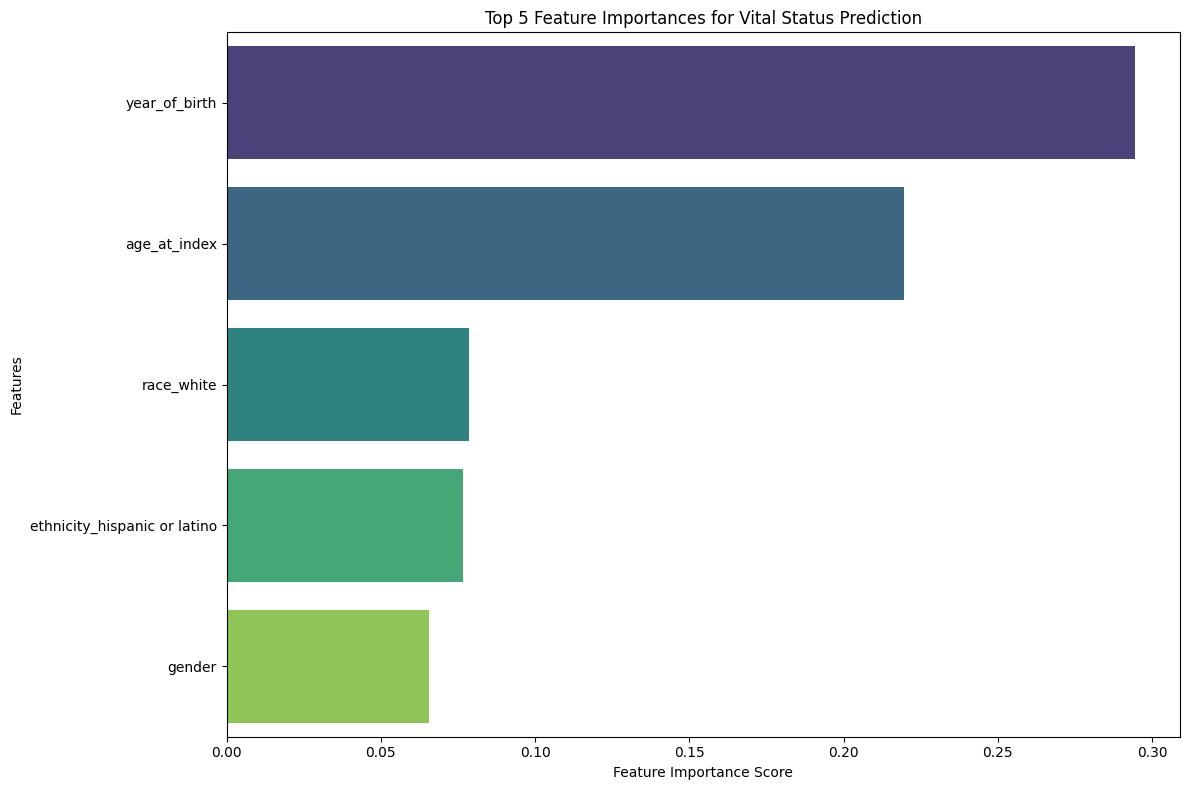

In [ ]:
# Get feature importances from the trained Random Forest classifier (with 'year_of_death' excluded)
feature_importances = best_rf.feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
feature_importances_series = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance in descending order
sorted_features = feature_importances_series.sort_values(ascending=False)

# Display the top 5 most important features
print("Top 5 Most Important Features for predicting Vital Status:")
print(sorted_features.head(5))

# Plot the top 5 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')
plt.title('Top 5 Feature Importances for Vital Status Prediction')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### ROC Curve and AUC Score for Random Forest

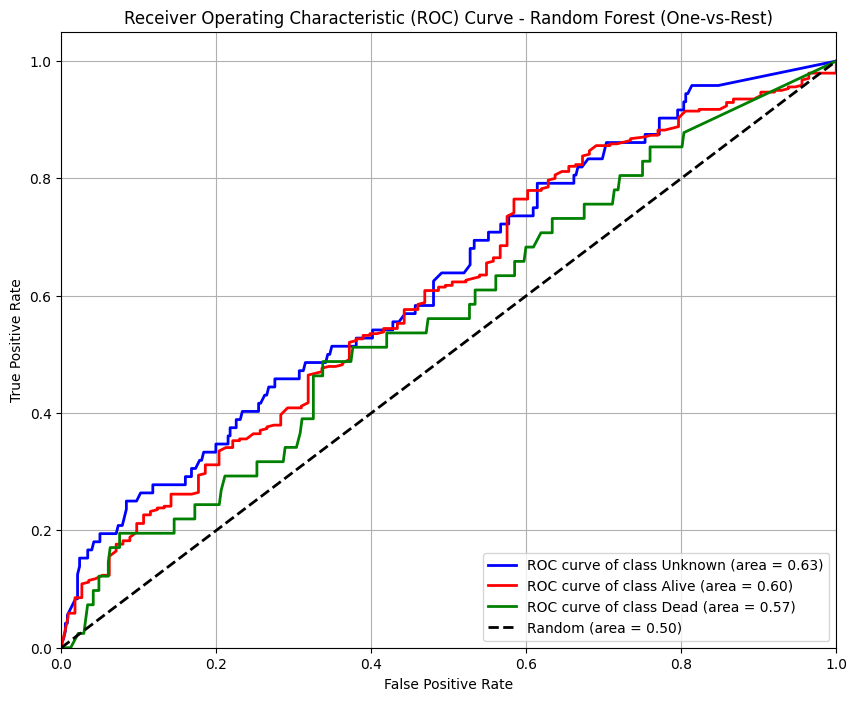

AUC scores per class:
Class Unknown: 0.63
Class Alive: 0.60
Class Dead: 0.57


In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (assuming '1' is the positive class or it's a multi-class problem, we need to adapt)
# For multi-class, we usually calculate AUC per class or micro/macro average
# Here, 'vital_status' has 3 classes (0, 1, 2). Let's treat '1' (Alive) as the positive class for demonstration purposes, or plot for all classes.

# First, we need the probabilities for each class
y_pred_proba_rf = best_rf.predict_proba(X_test)

# We'll calculate ROC for each class. The target 'vital_status' has classes 0, 1, 2.
n_classes = len(np.unique(y_test))

# Store FPR, TPR, and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Binarize the true labels for the current class (one-vs-rest)
    y_test_binarized = (y_test == i).astype(int)

    # Check if there are both positive and negative samples for this class in y_test
    if len(np.unique(y_test_binarized)) < 2:
        print(f"Warning: Class {i} has only one class present in y_test. Cannot compute ROC curve.")
        fpr[i] = None
        tpr[i] = None
        roc_auc[i] = None
        continue

    # Compute ROC curve and ROC area for each class
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized, y_pred_proba_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
class_labels = {0: 'Unknown', 1: 'Alive', 2: 'Dead'} # Map vital_status to meaningful labels

for i in range(n_classes):
    if fpr[i] is not None and tpr[i] is not None:
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                 label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("AUC scores per class:")
for i in range(n_classes):
    if roc_auc[i] is not None:
        print(f"Class {class_labels[i]}: {roc_auc[i]:0.2f}")

XGBoost

In [ ]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize XGBoost Classifier with regularization parameters
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(np.unique(y_train_resampled)), # Number of unique classes in target
    eval_metric='mlogloss', # Evaluation metric for multi-class classification
    random_state=42,
    early_stopping_rounds=50,
    reg_alpha=0.1,
    reg_lambda=0.1
)

# Train the model with early stopping by passing early_stopping_rounds directly
xgb_classifier.fit(
    X_train_resampled,
    y_train_resampled,
    eval_set=[(X_test, y_test)], # Use the test set for early stopping evaluation

    verbose=False # Set to True to see boosting round progress
)

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
print("\nXGBoost Classifier Performance (with SMOTE and Early Stopping):")
# Check if best_iteration exists, it might not if early stopping didn't trigger or version is old
if hasattr(xgb_classifier, 'best_iteration'):
    print(f"Best iteration: {xgb_classifier.best_iteration}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier Performance (with SMOTE and Early Stopping):
Best iteration: 19
Accuracy: 0.5828

Confusion Matrix:
[[ 28  33  11]
 [ 60 226  54]
 [ 13  18  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.39      0.32        72
           1       0.82      0.66      0.73       340
           2       0.13      0.24      0.17        41

    accuracy                           0.58       453
   macro avg       0.41      0.43      0.41       453
weighted avg       0.67      0.58      0.62       453



In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import numpy as np

# -----------------------------
# 1. Prepare data
# -----------------------------


X = df_q1.drop('vital_status', axis=1)
y = df_q1['vital_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set class distribution:")
print(y_train.value_counts())

# -----------------------------
# 2. Build SMOTE + XGBoost pipeline
# -----------------------------
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        tree_method='hist'
    ))
])

# -----------------------------
# 3. Hyperparameter search space
# -----------------------------
param_dist = {
    'xgb__n_estimators': [200, 400, 600],
    'xgb__max_depth': [3, 5, 7, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__gamma': [0, 0.1, 0.3, 0.5]
}

# -----------------------------
# 4. Stratified K-Fold CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 5. RandomizedSearchCV (faster than GridSearch)
# -----------------------------
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_macro',       # best for imbalanced classes
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("\nStarting XGBoost hyperparameter tuning...")
search.fit(X_train, y_train)

# -----------------------------
# 6. Best model + evaluation
# -----------------------------
print("\nBest Parameters:")
print(search.best_params_)

print(f"\nBest CV Score (F1-macro): {search.best_score_:.4f}")

best_xgb = search.best_estimator_

# Predict on test set
y_pred = best_xgb.predict(X_test)

print("\nXGBoost Performance (Tuned):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training set class distribution:
vital_status
1    793
0    169
2     95
Name: count, dtype: int64

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 600, 'xgb__min_child_weight': 3, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.5, 'xgb__colsample_bytree': 0.6}

Best CV Score (F1-macro): 0.4016

XGBoost Performance (Tuned):
Accuracy: 0.5982

Confusion Matrix:
[[ 27  34  11]
 [ 57 234  49]
 [ 10  21  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.38      0.33        72
           1       0.81      0.69      0.74       340
           2       0.14      0.24      0.18        41

    accuracy                           0.60       453
   macro avg       0.41      0.44      0.42       453
weighted avg       0.67      0.60      0.63       453



In [ ]:
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train_resampled)),
    eval_metric='mlogloss',
    random_state=42,

    # Best parameters from CV
    subsample=0.6,
    n_estimators=600,
    min_child_weight=3,
    max_depth=3,
    learning_rate=0.05,
    gamma=0.5,
    colsample_bytree=0.6,

    # Regularization
    reg_alpha=0.1,
    reg_lambda=0.1,

    # Early stopping
    early_stopping_rounds=50
)

# Train with early stopping
xgb_classifier.fit(
    X_train_resampled,
    y_train_resampled,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predict
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate
print("\nXGBoost Classifier Performance (Tuned + Early Stopping):")
if hasattr(xgb_classifier, 'best_iteration'):
    print(f"Best iteration: {xgb_classifier.best_iteration}")

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier Performance (Tuned + Early Stopping):
Best iteration: 251
Accuracy: 0.5784

Confusion Matrix:
[[ 27  33  12]
 [ 60 227  53]
 [ 13  20   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.38      0.31        72
           1       0.81      0.67      0.73       340
           2       0.11      0.20      0.14        41

    accuracy                           0.58       453
   macro avg       0.40      0.41      0.40       453
weighted avg       0.66      0.58      0.61       453



Top 10 Most Important Features for predicting Vital Status (XGBoost):
country_of_residence_at_enrollment_United States    0.092951
race_white                                          0.088489
year_of_birth                                       0.073597
gender                                              0.071790
ethnicity_hispanic or latino                        0.069225
ethnicity_not hispanic or latino                    0.067510
country_of_residence_at_enrollment_Bahamas          0.065349
age_at_index                                        0.059442
race_black or african american                      0.057028
country_of_residence_at_enrollment_Canada           0.055924
dtype: float32


/tmp/ipykernel_368/3187487921.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_sorted_features.head(10).values, y=xgb_sorted_features.head(10).index, palette='magma')


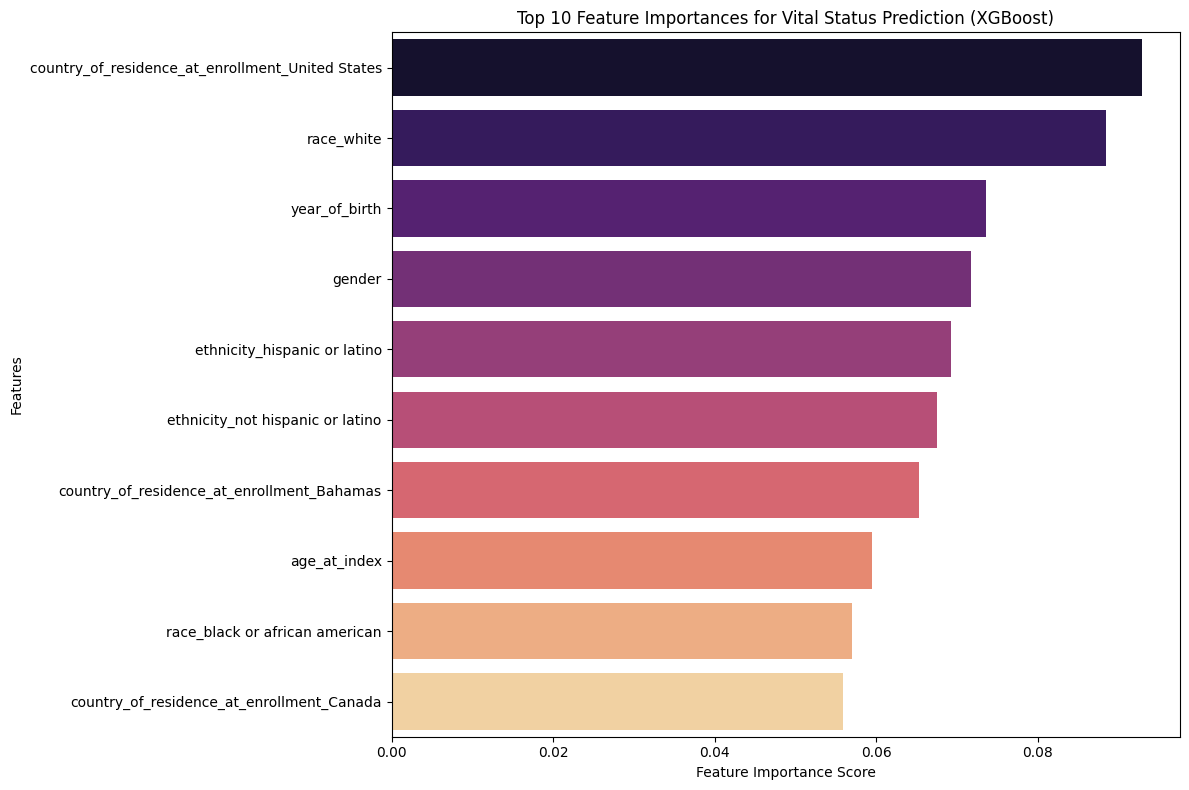

In [ ]:
# Get feature importances from the trained XGBoost classifier
xgb_feature_importances = xgb_classifier.feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
xgb_feature_importances_series = pd.Series(xgb_feature_importances, index=X.columns)

# Sort the features by importance in descending order
xgb_sorted_features = xgb_feature_importances_series.sort_values(ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features for predicting Vital Status (XGBoost):")
print(xgb_sorted_features.head(10))

# Plot the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_sorted_features.head(10).values, y=xgb_sorted_features.head(10).index, palette='magma')
plt.title('Top 10 Feature Importances for Vital Status Prediction (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Neural Network

### Neural Network Analysis with Hyperparameter Tuning

In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from scikeras.wrappers import KerasClassifier
from imblearn.over_sampling import SMOTE

# --- 1. Data Preparation for Neural Network ---

# Drop 'year_of_death' as it has many missing values and was problematic in previous steps.
# We already dropped it from df_q1, so df_q1 is already clean for this step.

# Define features (X_nn) and target (y_nn) from df_q1
X_nn = df_q1.drop('vital_status', axis=1)
y_nn = df_q1['vital_status']

# Split the data into training and testing sets
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.3, random_state=42, stratify=y_nn)

print("Original training set class distribution for NN:")
print(y_train_nn.value_counts())

# Apply SMOTE to the training data for class imbalance
sm_nn = SMOTE(random_state=42)
X_train_resampled_nn, y_train_resampled_nn = sm_nn.fit_resample(X_train_nn, y_train_nn)

print("\nResampled training set class distribution for NN:")
print(y_train_resampled_nn.value_counts())

# Standardize numerical features
scaler_nn = StandardScaler()

# Identify numerical columns for scaling
numerical_cols_nn = X_train_resampled_nn.select_dtypes(include=np.number).columns

# Apply scaling
X_train_scaled_nn = X_train_resampled_nn.copy()
X_test_scaled_nn = X_test_nn.copy()

X_train_scaled_nn[numerical_cols_nn] = scaler_nn.fit_transform(X_train_resampled_nn[numerical_cols_nn])
X_test_scaled_nn[numerical_cols_nn] = scaler_nn.transform(X_test_nn[numerical_cols_nn])

print("\nData preparation complete. X_train_scaled_nn and X_test_scaled_nn are ready for Neural Network.")

Original training set class distribution for NN:
vital_status
1    793
0    169
2     95
Name: count, dtype: int64

Resampled training set class distribution for NN:
vital_status
1    793
0    793
2    793
Name: count, dtype: int64

Data preparation complete. X_train_scaled_nn and X_test_scaled_nn are ready for Neural Network.


In [ ]:
# --- 2. Define the Keras model building function for GridSearchCV ---
def create_nn_model(num_hidden_layers=1, num_neurons=32, learning_rate=0.001, activation='relu', optimizer='adam'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled_nn.shape[1],))) # Input layer

    # Hidden layers
    for _ in range(num_hidden_layers):
        model.add(layers.Dense(num_neurons, activation=activation))

    # Output layer (3 classes: 0, 1, 2 for vital_status)
    model.add(layers.Dense(len(np.unique(y_nn)), activation='softmax'))

    # Choose optimizer based on parameter
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("Keras model building function defined.")

Keras model building function defined.


In [ ]:
# --- 3. Manual Hyperparameter Tuning Loop ---

from itertools import product

# Define the parameter grid for tuning
# Note: 'model__' prefixes are removed for direct use in create_nn_model
param_grid_nn_direct = {
    'num_hidden_layers': [1, 2],
    'num_neurons': [64, 128],
    'learning_rate': [0.001, 0.01],
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64],
    'epochs': [20, 30] # Reduced epochs for faster execution during tuning
}

_best_accuracy_global = 0
_best_params_global = None
_best_nn_model_global = None # To store the actual Keras model
_best_history_global = None # To store the training history of the best model

# Get all parameter combinations
keys = param_grid_nn_direct.keys()
values = param_grid_nn_direct.values()
param_combinations = list(product(*values))

print("Starting manual hyperparameter tuning loop for Neural Network. This may take some time...")
print(f"Total combinations to test: {len(param_combinations)}")

for i, params_tuple in enumerate(param_combinations):
    current_params = dict(zip(keys, params_tuple))

    # Extract parameters for model creation
    num_hidden_layers = current_params['num_hidden_layers']
    num_neurons = current_params['num_neurons']
    learning_rate = current_params['learning_rate']
    activation = current_params['activation']
    optimizer_name = current_params['optimizer'] # Renamed to avoid conflict with model instance

    # Extract parameters for model fitting
    batch_size = current_params['batch_size']
    epochs = current_params['epochs']

    # Create the Keras model
    model = create_nn_model(
        num_hidden_layers=num_hidden_layers,
        num_neurons=num_neurons,
        learning_rate=learning_rate,
        activation=activation,
        optimizer=optimizer_name
    )

    # Train the model and capture history
    # Use the resampled training data
    history = model.fit(X_train_scaled_nn, y_train_resampled_nn,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0,
                        validation_data=(X_test_scaled_nn, y_test_nn)) # Add validation data

    # Evaluate the model on the test set
    # Using X_test_scaled_nn and y_test_nn as a validation proxy for tuning
    _, accuracy = model.evaluate(X_test_scaled_nn, y_test_nn, verbose=0)

    # Check if this is the best model so far
    if accuracy > _best_accuracy_global:
        _best_accuracy_global = accuracy
        _best_params_global = current_params
        _best_nn_model_global = model # Store the actual Keras model
        _best_history_global = history # Store the history of the best model

print("\nManual hyperparameter tuning complete.")

print("\nBest parameters found:")
print(_best_params_global)
print(f"Best accuracy achieved: {_best_accuracy_global:.4f}")

Starting manual hyperparameter tuning loop for Neural Network. This may take some time...
Total combinations to test: 128

Manual hyperparameter tuning complete.

Best parameters found:
{'num_hidden_layers': 2, 'num_neurons': 64, 'learning_rate': 0.001, 'activation': 'relu', 'optimizer': 'adam', 'batch_size': 64, 'epochs': 30}
Best accuracy achieved: 0.6203


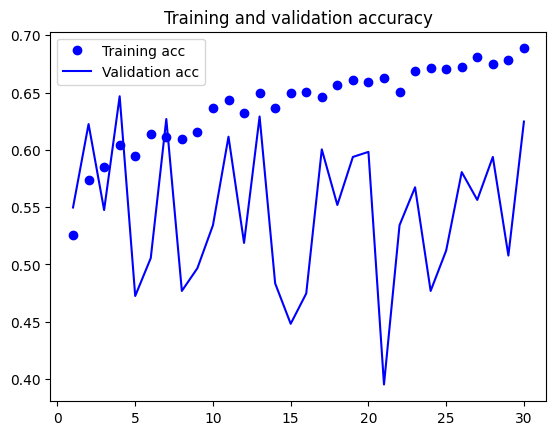

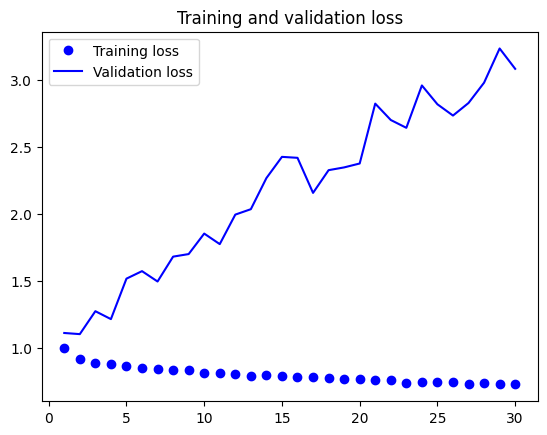

In [ ]:
acc = _best_history_global.history['accuracy']
val_acc = _best_history_global.history['val_accuracy']
loss = _best_history_global.history['loss']
val_loss = _best_history_global.history['val_loss']

epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

The best epoch appears to be around epoch 12.

Retraining with epoch 12.

In [ ]:
update_model = create_nn_model(
        num_hidden_layers=2,
        num_neurons=64,
        learning_rate=0.001,
        activation='relu',
        optimizer='adam'
    )

update_model.fit(X_train_scaled_nn, y_train_resampled_nn,
                        epochs=12,
                        batch_size=64,
                        verbose=0,
                        validation_data=(X_test_scaled_nn, y_test_nn))

_, update_accuracy = update_model.evaluate(X_test_scaled_nn, y_test_nn, verbose=0)
print(f"Best accuracy achieved: {update_accuracy:.4f}")

Best accuracy achieved: 0.5563


In [ ]:
# --- 4. Evaluate the best Neural Network model ---

print("\nBest parameters found by manual tuning:")
print(update_model)

# Get the best estimator (the trained model with best parameters)
best_nn_model = update_model

# Make predictions on the scaled test set
y_pred_nn = np.argmax(best_nn_model.predict(X_test_scaled_nn), axis=-1)

# Evaluate the model
print("\nNeural Network Classifier Performance (with SMOTE, Scaling, and Tuned Parameters):")
print(f"Accuracy: {accuracy_score(y_test_nn, y_pred_nn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_nn, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test_nn, y_pred_nn))


Best parameters found by manual tuning:
<Sequential name=sequential_131, built=True>
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Neural Network Classifier Performance (with SMOTE, Scaling, and Tuned Parameters):
Accuracy: 0.5563

Confusion Matrix:
[[ 34  24  14]
 [ 82 206  52]
 [ 13  16  12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.47      0.34        72
           1       0.84      0.61      0.70       340
           2       0.15      0.29      0.20        41

    accuracy                           0.56       453
   macro avg       0.42      0.46      0.41       453
weighted avg       0.68      0.56      0.60       453



Calculating permutation importance for the best Neural Network model, focusing on 'vital_status' class 2 (Dead)...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Top 10 Most Important Features for Predicting 'vital_status' Class 2 (Dead) (Neural Network - Permutation Importance):
year_of_birth                                       0.061458
ethnicity_not hispanic or latino                    0.054266
age_at_index                                        0.045396
race_white                                          0.029415
country_of_residence_at_enrollment_United States    0.020402
race_unknown                                        0.016981
ethnicity_hispanic or latino                        0.016315
country_of_residence_at_enrollment_New Zealand      0.013523
race_black or african american                      0.011970
country_of_residence_at_enrollment_Canada           0.011409
dtype: float64


/tmp/ipykernel_368/1421883744.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_nn_class_2.head(10).values, y=feature_importances_nn_class_2.head(10).index, palette='viridis')


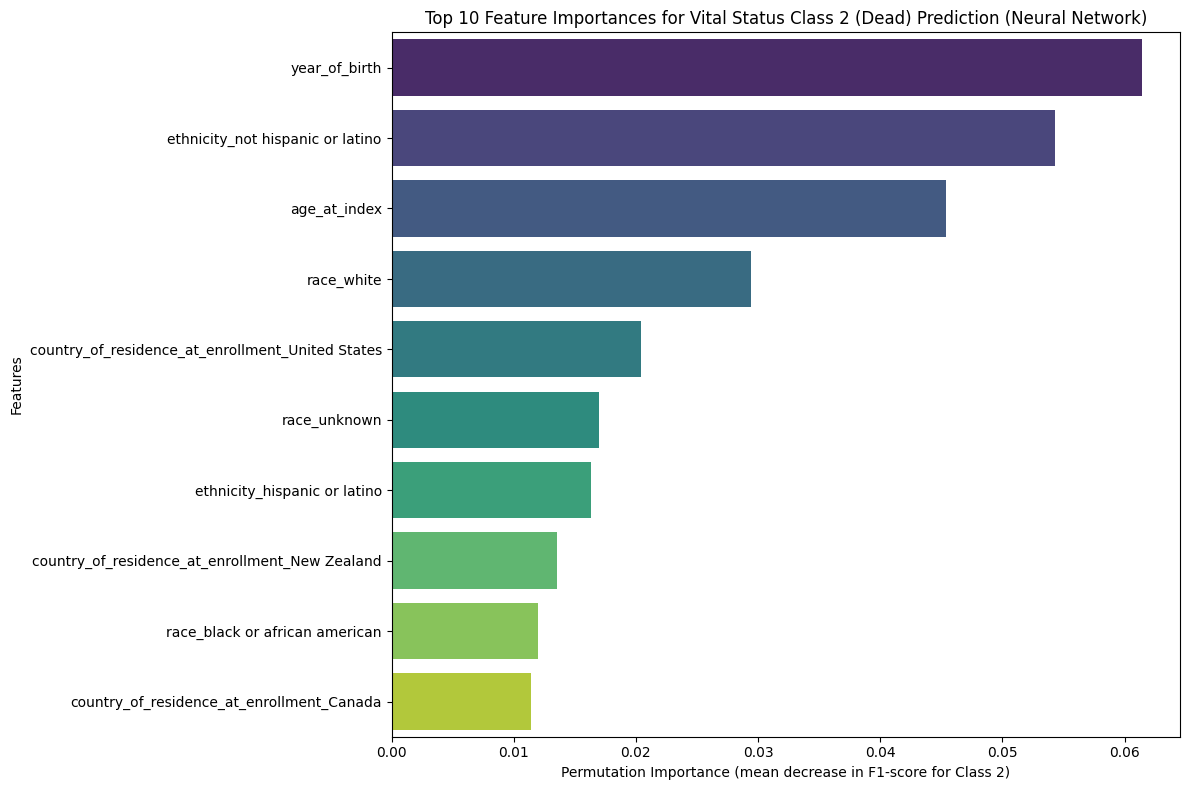

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Calculating permutation importance for the best Neural Network model, focusing on 'vital_status' class 2 (Dead)...")

# Custom scorer for F1-score of class 2 (Dead)
def f1_scorer_class_2(y_true, y_pred):
    # Convert probabilities to class labels for multi-class classification
    y_pred_labels = np.argmax(y_pred, axis=-1)
    return f1_score(y_true, y_pred_labels, labels=[2], average='micro')

scorer_class_2 = make_scorer(f1_scorer_class_2) # Removed needs_proba=True

# Calculate permutation importance
# The _best_nn_model_global is already compiled and trained.
# X_test_scaled_nn and y_test_nn are the appropriate datasets for evaluation.
results_class_2 = permutation_importance(update_model, X_test_scaled_nn, y_test_nn,
                                         scoring=scorer_class_2, n_repeats=10, random_state=42, n_jobs=-1)

# Organize results
sorted_idx_class_2 = results_class_2.importances_mean.argsort()[::-1] # Sort in descending order
feature_importances_nn_class_2 = pd.Series(results_class_2.importances_mean[sorted_idx_class_2], index=X_test_scaled_nn.columns[sorted_idx_class_2])
feature_importances_std_nn_class_2 = pd.Series(results_class_2.importances_std[sorted_idx_class_2], index=X_test_scaled_nn.columns[sorted_idx_class_2])

print("\nTop 10 Most Important Features for Predicting 'vital_status' Class 2 (Dead) (Neural Network - Permutation Importance):")
print(feature_importances_nn_class_2.head(10))

# Plot the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances_nn_class_2.head(10).values, y=feature_importances_nn_class_2.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances for Vital Status Class 2 (Dead) Prediction (Neural Network)')
plt.xlabel('Permutation Importance (mean decrease in F1-score for Class 2)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Bayesian Network

In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 11.8 MB/s eta 0:00:00


Age influences ethnicity/race distributions (cohort effects).

Ethnicity and race often correlate with gender distributions in clinical datasets.

Country of residence is downstream of demographic identity.

Vital status is the final outcome.

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
# Define the DAG
model = DiscreteBayesianNetwork([
    ('demographic.age_at_index', 'demographic.vital_status'),
    ('demographic.country_of_residence_at_enrollment', 'demographic.ethnicity'),
    ('demographic.country_of_residence_at_enrollment', 'demographic.race'),
    ('demographic.race', 'demographic.vital_status'),
    ('demographic.ethnicity', 'demographic.vital_status'),
    ('demographic.gender', 'demographic.vital_status')
])

In [ ]:
from pgmpy.estimators import MaximumLikelihoodEstimator

# Ensure only the columns used in the model are passed, and that they are all categorical
model_columns = [
    'demographic.age_at_index',
    'demographic.ethnicity',
    'demographic.race',
    'demographic.gender',
    'demographic.country_of_residence_at_enrollment',
    'demographic.vital_status'
]

# Filter df_bayesian to include only the columns used in the model
df_bayesian_filtered = df_bayesian[model_columns].copy()

model.fit(df_bayesian_filtered)

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [ ]:
for cpd in model.get_cpds():
    print(cpd)

+---------------------------------+------------+
| demographic.age_at_index(12-14) | 0.00993377 |
+---------------------------------+------------+
| demographic.age_at_index(15-17) | 0.00794702 |
+---------------------------------+------------+
| demographic.age_at_index(18+)   | 0.00198675 |
+---------------------------------+------------+
| demographic.age_at_index(3-5)   | 0.491391   |
+---------------------------------+------------+
| demographic.age_at_index(6-8)   | 0.176821   |
+---------------------------------+------------+
| demographic.age_at_index(9-11)  | 0.0443709  |
+---------------------------------+------------+
| demographic.age_at_index(<=2)   | 0.26755    |
+---------------------------------+------------+
+-----------------------------------+-----+--------------------------------+
| demographic.age_at_index          | ... | demographic.age_at_index(<=2)  |
+-----------------------------------+-----+--------------------------------+
| demographic.ethnicity           

In [ ]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)

In [ ]:
result = infer.query(
    ['demographic.vital_status'],
    evidence={'demographic.country_of_residence_at_enrollment': 'United States'}
)

print(result)

+-----------------------------------+---------------------------------+
| demographic.vital_status          |   phi(demographic.vital_status) |
+===================================+=================================+
| demographic.vital_status(Alive)   |                          0.7424 |
+-----------------------------------+---------------------------------+
| demographic.vital_status(Dead)    |                          0.0909 |
+-----------------------------------+---------------------------------+
| demographic.vital_status(Unknown) |                          0.1667 |
+-----------------------------------+---------------------------------+


In [ ]:
result = infer.query(
    ['demographic.vital_status'],
    evidence={
        'demographic.age_at_index': '3-5',
        'demographic.gender': 'male'
    }
)

print(result)

+-----------------------------------+---------------------------------+
| demographic.vital_status          |   phi(demographic.vital_status) |
+===================================+=================================+
| demographic.vital_status(Alive)   |                          0.7629 |
+-----------------------------------+---------------------------------+
| demographic.vital_status(Dead)    |                          0.0800 |
+-----------------------------------+---------------------------------+
| demographic.vital_status(Unknown) |                          0.1571 |
+-----------------------------------+---------------------------------+


In [ ]:
result = infer.query(
    ['demographic.vital_status'],
    evidence={
        'demographic.age_at_index': '3-5',
        'demographic.gender': 'female'
    }
)

print(result)

+-----------------------------------+---------------------------------+
| demographic.vital_status          |   phi(demographic.vital_status) |
+===================================+=================================+
| demographic.vital_status(Alive)   |                          0.7855 |
+-----------------------------------+---------------------------------+
| demographic.vital_status(Dead)    |                          0.0600 |
+-----------------------------------+---------------------------------+
| demographic.vital_status(Unknown) |                          0.1544 |
+-----------------------------------+---------------------------------+


In [ ]:
result = infer.query(
    ['demographic.race'],
    evidence={'demographic.ethnicity': 'hispanic or latino'}
)

print(result)

+-------------------------------------------------------------+-------------------------+
| demographic.race                                            |   phi(demographic.race) |
+=============================================================+=========================+
| demographic.race(american indian or alaska native)          |                  0.0030 |
+-------------------------------------------------------------+-------------------------+
| demographic.race(asian)                                     |                  0.0344 |
+-------------------------------------------------------------+-------------------------+
| demographic.race(black or african american)                 |                  0.0622 |
+-------------------------------------------------------------+-------------------------+
| demographic.race(native hawaiian or other pacific islander) |                  0.0015 |
+-------------------------------------------------------------+-------------------------+
| demograp

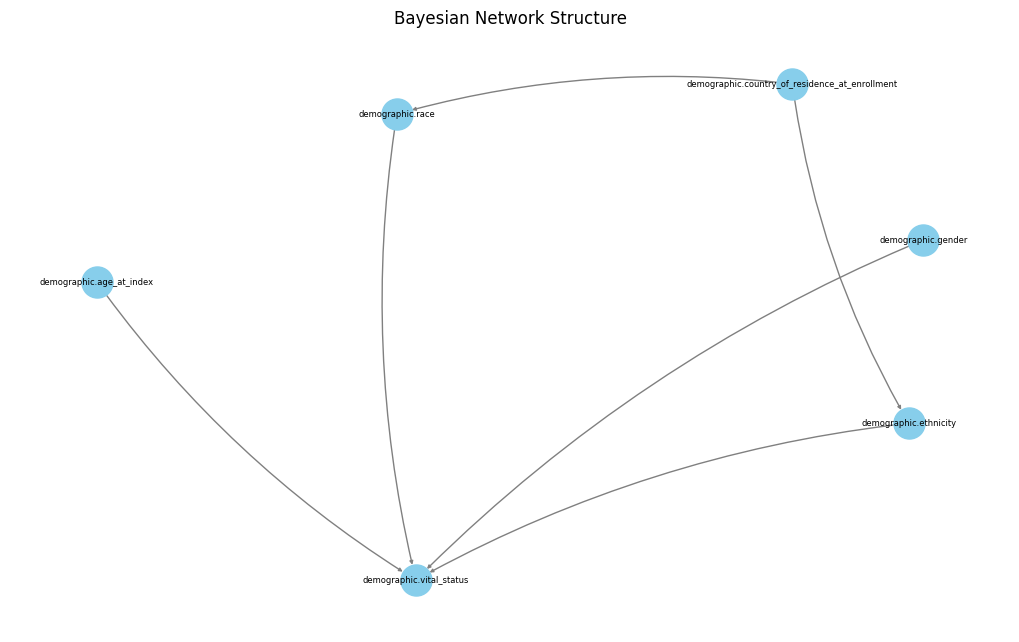

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert pgmpy model to a real NetworkX DiGraph
G = nx.DiGraph()
G.add_nodes_from(model.nodes())
G.add_edges_from(model.edges())

plt.figure(figsize=(10,6))
pos = nx.spring_layout(G)  # Layout for better spacing

nx.draw(
    G, pos,
    with_labels=True,
    node_size=500,
    font_size=6,
    arrowsize=5,
    node_color='skyblue',
    edge_color='gray',
    connectionstyle='arc3,rad=0.1'
)

plt.title('Bayesian Network Structure')
plt.show()

#Analysis of demographics and diagnosis typing

Initialize one-hot diagnosis df

In [ ]:
# Identify all 'demographic' columns in df_one_hot
demographic_cols = [col for col in df_one_hot.columns if col.startswith('demographic.') or col.startswith('diagnoses.')]

# Create df_demographic by selecting these columns from df_one_hot
df_diag = df_one_hot[demographic_cols].copy()

print("Head of the new df_demographic DataFrame:")
display(df_diag.head())

print("\nInfo of the new df_demographic DataFrame:")
df_diag.info()

Head of the new df_demographic DataFrame:


,demographic.age_at_index,demographic.gender,demographic.vital_status,demographic.year_of_birth,demographic.year_of_death,diagnoses.age_at_diagnosis,diagnoses.days_to_last_follow_up,diagnoses.primary_diagnosis,diagnoses.year_of_diagnosis,demographic.country_of_residence_at_enrollment_Albania,...,diagnoses.morphology_9728/3,diagnoses.morphology_9800/3,diagnoses.morphology_9801/3,diagnoses.morphology_9820/3,diagnoses.morphology_9823/3,diagnoses.morphology_9835/3,diagnoses.morphology_9836/3,diagnoses.morphology_Unknown,diagnoses.tissue_or_organ_of_origin_Blood,diagnoses.tissue_or_organ_of_origin_Bone marrow
0,6,0,1,2006,NaN,2231,2976.0,Common precursor B ALL,2012,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,6,0,2,2003,2013,2492,1270.0,Common precursor B ALL,2010,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2,0,0,2009,NaN,1026,439.0,Common precursor B ALL,2012,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,15,0,0,1992,NaN,5675,2077.0,"Leukemia, NOS",2007,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2,0,1,2007,NaN,1040,3625.0,Common precursor B ALL,2010,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



Info of the new df_demographic DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 39 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   demographic.age_at_index                                           1510 non-null   int64  
 1   demographic.gender                                                 1510 non-null   int64  
 2   demographic.vital_status                                           1510 non-null   int64  
 3   demographic.year_of_birth                                          1510 non-null   int64  
 4   demographic.year_of_death                                          136 non-null    object 
 5   diagnoses.age_at_diagnosis                                         1510 non-null   int64  
 6   diagnoses.days_to_last_follow_up                                   1510 non-n

In [ ]:
# Drop 'demographic.vital_status ' from df_diag
df_diag = df_diag.drop(columns=['demographic.vital_status'])

In [ ]:
df_q2 = df_diag.copy()
df_q2 = df_q2.drop(columns='demographic.year_of_death')
df_q2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 37 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   demographic.age_at_index                                           1510 non-null   int64  
 1   demographic.gender                                                 1510 non-null   int64  
 2   demographic.year_of_birth                                          1510 non-null   int64  
 3   diagnoses.age_at_diagnosis                                         1510 non-null   int64  
 4   diagnoses.days_to_last_follow_up                                   1510 non-null   float64
 5   diagnoses.primary_diagnosis                                        1510 non-null   object 
 6   diagnoses.year_of_diagnosis                                        1510 non-null   int64  
 7   demographic.country_of_r

In [ ]:
#Check target column for SMOTE use
df_q2['diagnoses.primary_diagnosis'].value_counts()

,count
diagnoses.primary_diagnosis,
Common precursor B ALL,1265
"Acute lymphoblastic leukemia, NOS",144
"Leukemia, NOS",57
"Acute leukemia, NOS",11
Precursor B-cell lymphoblastic leukemia,11
"Precursor cell lymphoblastic leukemia, NOS",7
"Precursor cell lymphoblastic leukemia, not phenotyped",7
Subacute lymphoid leukemia,2
Blastic plasmacytoid dendritic cell neoplasm,1


In [ ]:
df_smote = df_q2.copy()

# Identify rare classes
counts = df_q2['diagnoses.primary_diagnosis'].value_counts()

rare_classes = counts[counts < 6].index

df_smote['diagnoses.primary_diagnosis'] = df_smote['diagnoses.primary_diagnosis'].replace(rare_classes, 'Other')
df_smote['diagnoses.primary_diagnosis'].value_counts()


,count
diagnoses.primary_diagnosis,
Common precursor B ALL,1265
"Acute lymphoblastic leukemia, NOS",144
"Leukemia, NOS",57
"Acute leukemia, NOS",11
Precursor B-cell lymphoblastic leukemia,11
Other,8
"Precursor cell lymphoblastic leukemia, NOS",7
"Precursor cell lymphoblastic leukemia, not phenotyped",7


In [ ]:
# Columns for binary conversion
binary_cols_mapping = {
    'diagnoses.primary_diagnosis': {'Common precursor B ALL': 7,
                                    'Acute lymphoblastic leukemia, NOS': 6,
                                    'Leukemia, NOS': 5,
                                    'Acute leukemia, NOS': 4,
                                    'Precursor B-cell lymphoblastic leukemia': 3,
                                    'Precursor cell lymphoblastic leukemia, NOS': 2,
                                    'Precursor cell lymphoblastic leukemia, not phenotyped': 1,
                                    'Other': 0}
}

# Apply binary conversion
for col, mapping in binary_cols_mapping.items():
    df_smote[col] = df_smote[col].map(mapping)

In [ ]:
# Define features (X) and target (y)
X = df_smote.drop('diagnoses.primary_diagnosis', axis=1)

y = df_smote['diagnoses.primary_diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Original training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("\nRandom Forest Classifier Performance (with SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original training set class distribution:
diagnoses.primary_diagnosis
7    885
6    101
5     40
3      8
4      8
1      5
2      5
0      5
Name: count, dtype: int64

Resampled training set class distribution:
diagnoses.primary_diagnosis
7    885
5    885
1    885
6    885
3    885
2    885
0    885
4    885
Name: count, dtype: int64

Random Forest Classifier Performance (with SMOTE):
Accuracy: 0.9868

Confusion Matrix:
[[  0   0   0   0   0   0   2   1]
 [  0   0   0   0   0   0   2   0]
 [  0   0   2   0   0   0   0   0]
 [  0   0   0   3   0   0   0   0]
 [  0   0   0   0   3   0   0   0]
 [  0   0   0   0   0  17   0   0]
 [  1   0   0   0   0   0  42   0]
 [  0   0   0   0   0   0   0 380]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Top 5 Most Important Features for predicting Vital Status:
diagnoses.morphology_Unknown    0.117515
diagnoses.morphology_9800/3     0.114967
diagnoses.morphology_9801/3     0.109541
diagnoses.morphology_9835/3     0.105427
diagnoses.morphology_9728/3     0.103244
dtype: float64


/tmp/ipykernel_794/1190254120.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')


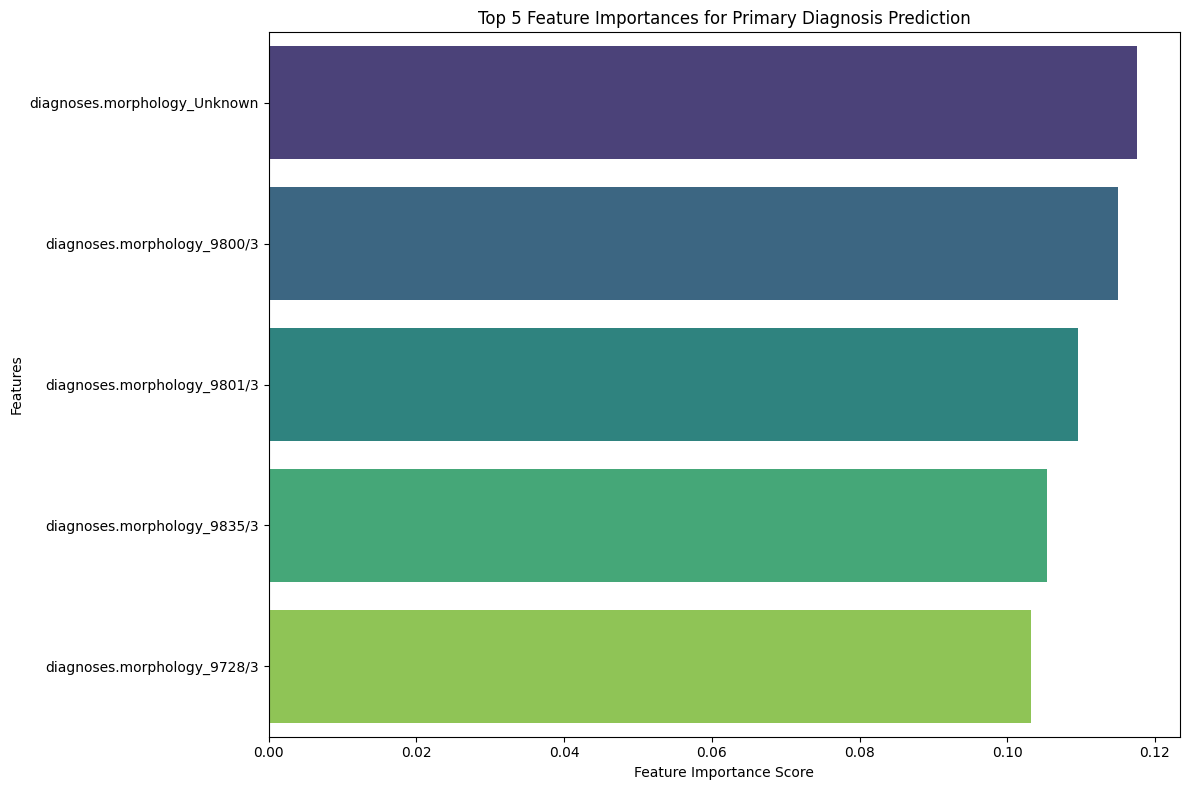

In [ ]:
# Get feature importances from the trained Random Forest classifier (with 'year_of_death' excluded)
feature_importances = rf_classifier.feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
feature_importances_series = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance in descending order
sorted_features = feature_importances_series.sort_values(ascending=False)

# Display the top 5 most important features
print("Top 5 Most Important Features for predicting Vital Status:")
print(sorted_features.head(5))

# Plot the top 5 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')
plt.title('Top 5 Feature Importances for Primary Diagnosis Prediction')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Ignore morphology

In [ ]:
df_smote = df_smote.drop(columns=[col for col in df_smote.columns if 'morphology' in col])
df_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 26 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   demographic.age_at_index                                           1510 non-null   int64  
 1   demographic.gender                                                 1510 non-null   int64  
 2   demographic.year_of_birth                                          1510 non-null   int64  
 3   diagnoses.age_at_diagnosis                                         1510 non-null   int64  
 4   diagnoses.days_to_last_follow_up                                   1510 non-null   float64
 5   diagnoses.primary_diagnosis                                        1510 non-null   int64  
 6   diagnoses.year_of_diagnosis                                        1510 non-null   int64  
 7   demographic.country_of_r

In [ ]:
# Define features (X) and target (y)
X = df_smote.drop('diagnoses.primary_diagnosis', axis=1)

y = df_smote['diagnoses.primary_diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Original training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("\nRandom Forest Classifier Performance (with SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original training set class distribution:
diagnoses.primary_diagnosis
7    885
6    101
5     40
3      8
4      8
1      5
2      5
0      5
Name: count, dtype: int64

Resampled training set class distribution:
diagnoses.primary_diagnosis
7    885
5    885
1    885
6    885
3    885
2    885
0    885
4    885
Name: count, dtype: int64

Random Forest Classifier Performance (with SMOTE):
Accuracy: 0.7748

Confusion Matrix:
[[  0   0   0   0   0   0   1   2]
 [  0   0   0   0   0   1   0   1]
 [  0   0   0   0   0   0   0   2]
 [  0   0   0   0   0   0   0   3]
 [  0   0   0   0   0   0   1   2]
 [  0   0   1   0   1   3   6   6]
 [  1   0   2   3   0   2  14  21]
 [  3   0   1   2   3  11  26 334]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Top 5 Most Important Features for predicting Primary Diangosis:
diagnoses.days_to_last_follow_up    0.165105
demographic.year_of_birth           0.146639
diagnoses.age_at_diagnosis          0.144324
diagnoses.year_of_diagnosis         0.140195
demographic.age_at_index            0.080565
dtype: float64


/tmp/ipykernel_368/4227881549.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')


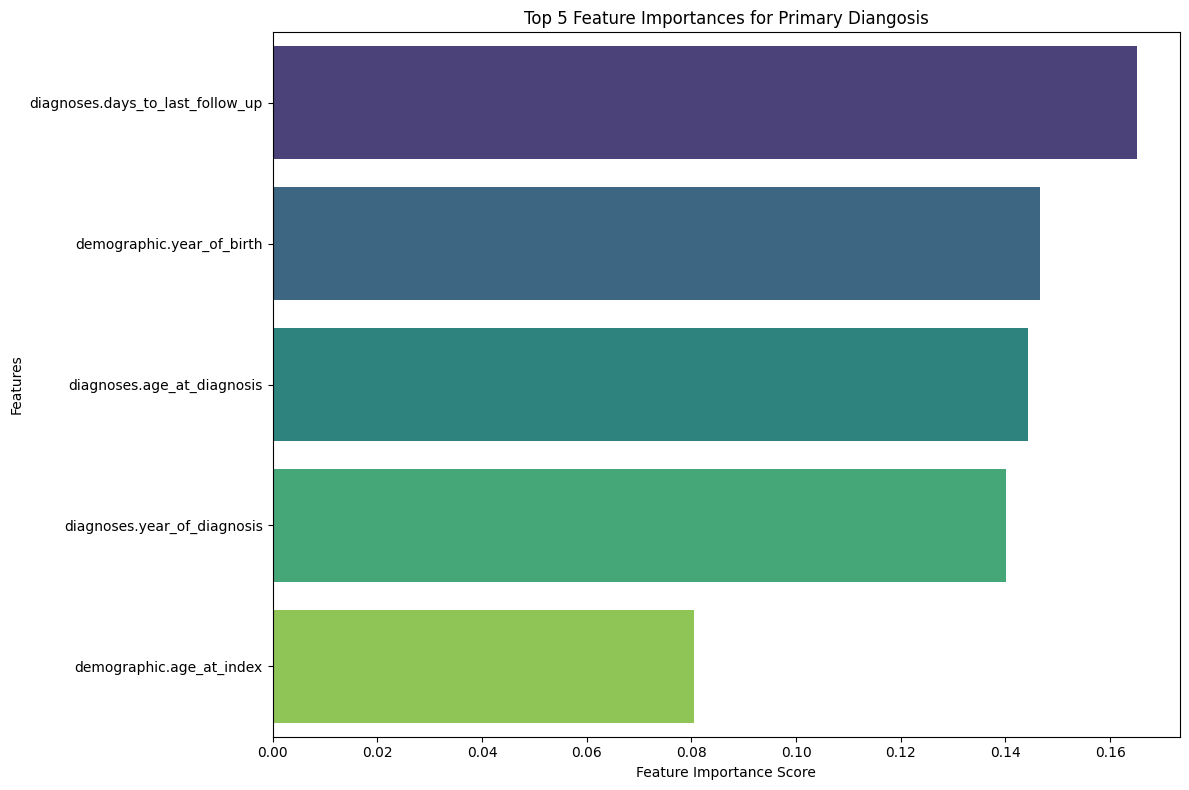

In [ ]:
# Get feature importances from the trained Random Forest classifier (with 'year_of_death' excluded)
feature_importances = rf_classifier.feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
feature_importances_series = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance in descending order
sorted_features = feature_importances_series.sort_values(ascending=False)

# Display the top 5 most important features
print("Top 5 Most Important Features for predicting Primary Diangosis:")
print(sorted_features.head(5))

# Plot the top 5 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')
plt.title('Top 5 Feature Importances for Primary Diangosis')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

XGBoost

In [ ]:
# Initialize XGBoost Classifier with regularization parameters
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(np.unique(y_train_resampled)), # Number of unique classes in target
    # use_label_encoder=False, # Removed as it's deprecated and might cause issues in some versions
    eval_metric='mlogloss', # Evaluation metric for multi-class classification
    random_state=42,
    early_stopping_rounds=50,  # Stop if validation metric doesn't improve for 50 rounds
    reg_alpha=0.1, # L1 regularization term on weights
    reg_lambda=0.1 # L2 regularization term on weights
)

# Train the model with early stopping by passing early_stopping_rounds directly
xgb_classifier.fit(
    X_train_resampled,
    y_train_resampled,
    eval_set=[(X_test, y_test)], # Use the test set for early stopping evaluation

    verbose=False # Set to True to see boosting round progress
)

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
print("\nXGBoost Classifier Performance (with SMOTE and Early Stopping):")
# Check if best_iteration exists, it might not if early stopping didn't trigger or version is old
if hasattr(xgb_classifier, 'best_iteration'):
    print(f"Best iteration: {xgb_classifier.best_iteration}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier Performance (with SMOTE and Early Stopping):
Best iteration: 17
Accuracy: 0.7461

Confusion Matrix:
[[  0   0   0   0   0   0   0   3]
 [  0   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   2]
 [  0   0   0   0   0   0   0   3]
 [  1   0   0   0   0   0   0   2]
 [  1   0   1   1   1   2   4   7]
 [  2   0   1   3   0   1  15  21]
 [  3   1   2   9   4  15  25 321]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.11      0.12      0.11        17
           6       0.33      0.35      0.34        43
           7       0.89      0.84      0.87       380

    accuracy                           0.75       453
   macro avg       0.17      0.16

Top 10 Most Important Features for predicting Primary Diagnosis (XGBoost):
demographic.country_of_residence_at_enrollment_Bahamas          0.128354
demographic.race_white                                          0.106147
diagnoses.year_of_diagnosis                                     0.102112
demographic.country_of_residence_at_enrollment_Albania          0.097341
demographic.race_asian                                          0.068555
demographic.country_of_residence_at_enrollment_Australia        0.059513
demographic.country_of_residence_at_enrollment_Canada           0.051922
demographic.country_of_residence_at_enrollment_United States    0.048864
demographic.year_of_birth                                       0.044828
diagnoses.tissue_or_organ_of_origin_Blood                       0.043471
dtype: float32


/tmp/ipykernel_368/1524680583.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_sorted_features.head(10).values, y=xgb_sorted_features.head(10).index, palette='magma')


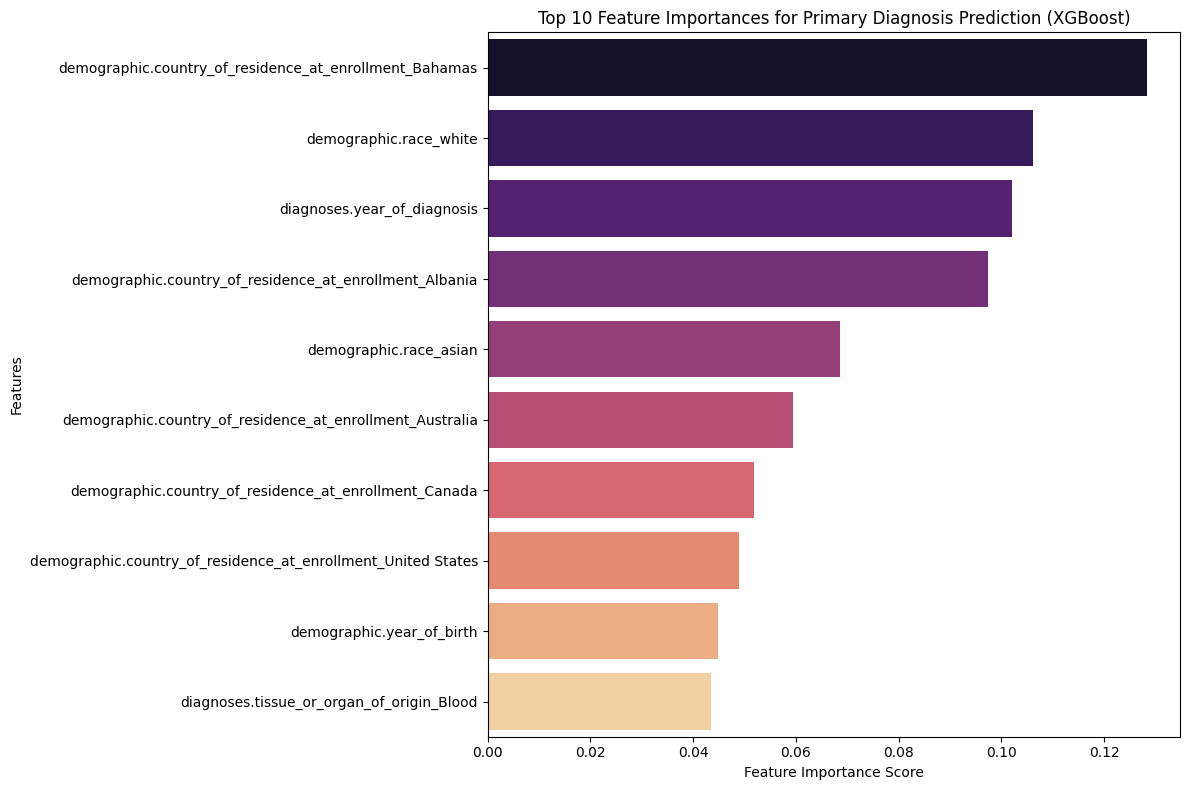

In [ ]:
# Get feature importances from the trained XGBoost classifier
xgb_feature_importances = xgb_classifier.feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
xgb_feature_importances_series = pd.Series(xgb_feature_importances, index=X.columns)

# Sort the features by importance in descending order
xgb_sorted_features = xgb_feature_importances_series.sort_values(ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features for predicting Primary Diagnosis (XGBoost):")
print(xgb_sorted_features.head(10))

# Plot the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_sorted_features.head(10).values, y=xgb_sorted_features.head(10).index, palette='magma')
plt.title('Top 10 Feature Importances for Primary Diagnosis Prediction (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Neural Network

In [ ]:
# Define features (X_nn) and target (y_nn) from df_q1
X_nn = df_smote.drop('diagnoses.primary_diagnosis', axis=1)
y_nn = df_smote['diagnoses.primary_diagnosis']

# Split the data into training and testing sets
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.3, random_state=42, stratify=y_nn)

print("Original training set class distribution for NN:")
print(y_train_nn.value_counts())

# Apply SMOTE to the training data for class imbalance
sm_nn = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled_nn, y_train_resampled_nn = sm_nn.fit_resample(X_train_nn, y_train_nn)

print("\nResampled training set class distribution for NN:")
print(y_train_resampled_nn.value_counts())

# Standardize numerical features
scaler_nn = StandardScaler()

# Identify numerical columns for scaling
numerical_cols_nn = X_train_resampled_nn.select_dtypes(include=np.number).columns

# Apply scaling
X_train_scaled_nn = X_train_resampled_nn.copy()
X_test_scaled_nn = X_test_nn.copy()

X_train_scaled_nn[numerical_cols_nn] = scaler_nn.fit_transform(X_train_resampled_nn[numerical_cols_nn])
X_test_scaled_nn[numerical_cols_nn] = scaler_nn.transform(X_test_nn[numerical_cols_nn])

print("\nData preparation complete. X_train_scaled_nn and X_test_scaled_nn are ready for Neural Network.")

Original training set class distribution for NN:
diagnoses.primary_diagnosis
7    885
6    101
5     40
3      8
4      8
1      5
2      5
0      5
Name: count, dtype: int64

Resampled training set class distribution for NN:
diagnoses.primary_diagnosis
7    885
5    885
1    885
6    885
3    885
2    885
0    885
4    885
Name: count, dtype: int64

Data preparation complete. X_train_scaled_nn and X_test_scaled_nn are ready for Neural Network.


In [ ]:
# --- 3. Manual Hyperparameter Tuning Loop ---

# Define the parameter grid for tuning
# Note: 'model__' prefixes are removed for direct use in create_nn_model
param_grid_nn_direct = {
    'num_hidden_layers': [1, 2],
    'num_neurons': [64, 128],
    'learning_rate': [0.001, 0.01],
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64],
    'epochs': [20, 30] # Reduced epochs for faster execution during tuning
}

_best_accuracy_global = 0
_best_params_global = None
_best_nn_model_global = None # To store the actual Keras model
_best_history_global = None # To store the training history of the best model

# Get all parameter combinations
keys = param_grid_nn_direct.keys()
values = param_grid_nn_direct.values()
param_combinations = list(product(*values))

print("Starting manual hyperparameter tuning loop for Neural Network. This may take some time...")
print(f"Total combinations to test: {len(param_combinations)}")

for i, params_tuple in enumerate(param_combinations):
    current_params = dict(zip(keys, params_tuple))

    # Extract parameters for model creation
    num_hidden_layers = current_params['num_hidden_layers']
    num_neurons = current_params['num_neurons']
    learning_rate = current_params['learning_rate']
    activation = current_params['activation']
    optimizer_name = current_params['optimizer'] # Renamed to avoid conflict with model instance

    # Extract parameters for model fitting
    batch_size = current_params['batch_size']
    epochs = current_params['epochs']

    # Create the Keras model
    model = create_nn_model(
        num_hidden_layers=num_hidden_layers,
        num_neurons=num_neurons,
        learning_rate=learning_rate,
        activation=activation,
        optimizer=optimizer_name
    )

    # Train the model and capture history
    # Use the resampled training data
    history = model.fit(X_train_scaled_nn, y_train_resampled_nn,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0,
                        validation_data=(X_test_scaled_nn, y_test_nn)) # Add validation data

    # Evaluate the model on the test set
    # Using X_test_scaled_nn and y_test_nn as a validation proxy for tuning
    _, accuracy = model.evaluate(X_test_scaled_nn, y_test_nn, verbose=0)

    # Check if this is the best model so far
    if accuracy > _best_accuracy_global:
        _best_accuracy_global = accuracy
        _best_params_global = current_params
        _best_nn_model_global = model # Store the actual Keras model
        _best_history_global = history # Store the history of the best model

print("\nManual hyperparameter tuning complete.")

print("\nBest parameters found:")
print(_best_params_global)
print(f"Best accuracy achieved: {_best_accuracy_global:.4f}")

Starting manual hyperparameter tuning loop for Neural Network. This may take some time...
Total combinations to test: 128

Manual hyperparameter tuning complete.

Best parameters found:
{'num_hidden_layers': 1, 'num_neurons': 128, 'learning_rate': 0.01, 'activation': 'relu', 'optimizer': 'rmsprop', 'batch_size': 32, 'epochs': 20}
Best accuracy achieved: 0.7881


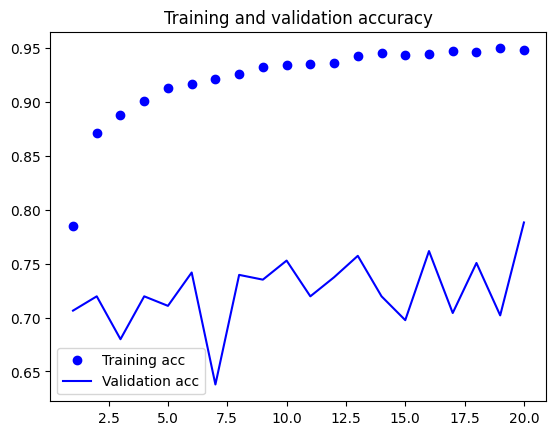

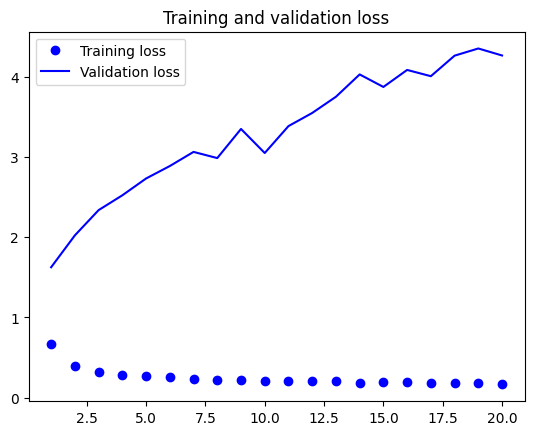

In [ ]:
acc = _best_history_global.history['accuracy']
val_acc = _best_history_global.history['val_accuracy']
loss = _best_history_global.history['loss']
val_loss = _best_history_global.history['val_loss']

epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Best epoch at 5

In [ ]:
update_model = create_nn_model(
        num_hidden_layers=1,
        num_neurons=128,
        learning_rate=0.01,
        activation='relu',
        optimizer='adam'
    )

update_model.fit(X_train_scaled_nn, y_train_resampled_nn,
                        epochs=5,
                        batch_size=32,
                        verbose=0,
                        validation_data=(X_test_scaled_nn, y_test_nn))

_, update_accuracy = update_model.evaluate(X_test_scaled_nn, y_test_nn, verbose=0)
print(f"Best accuracy achieved: {update_accuracy:.4f}")

Best accuracy achieved: 0.7528


In [ ]:
# --- 4. Evaluate the best Neural Network model ---

print("\nBest parameters found by manual tuning:")
print(update_model)

# Get the best estimator (the trained model with best parameters)
best_nn_model = update_model

# Make predictions on the scaled test set
y_pred_nn = np.argmax(best_nn_model.predict(X_test_scaled_nn), axis=-1)

# Evaluate the model
print("\nNeural Network Classifier Performance (with SMOTE, Scaling, and Tuned Parameters):")
print(f"Accuracy: {accuracy_score(y_test_nn, y_pred_nn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_nn, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test_nn, y_pred_nn))


Best parameters found by manual tuning:
<Sequential name=sequential_848, built=True>
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Neural Network Classifier Performance (with SMOTE, Scaling, and Tuned Parameters):
Accuracy: 0.7528

Confusion Matrix:
[[  0   0   0   0   0   0   2   1]
 [  0   0   0   0   0   0   2   0]
 [  0   0   0   0   0   0   0   2]
 [  0   0   0   0   0   0   0   3]
 [  0   0   0   0   0   1   1   1]
 [  1   0   1   0   0   4   6   5]
 [  2   0   3   1   0   3  19  15]
 [  2   1   0   4   3  19  33 318]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.15      0.24      0.18        17
           6       0.30      0.44      0.36        43
           7    


Calculating permutation importance for class 5...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Top 10 features for class 5:
demographic.age_at_index                           0.131737
diagnoses.age_at_diagnosis                         0.126253
diagnoses.year_of_diagnosis                        0.101044
demographic.gender                                 0.057227
demographic.ethnicity_not hispanic or latino       0.054376
demographic.ethnicity_hispanic or latino           0.044788
demographic.race_unknown                           0.041871
demographic.race_white                             0.038100
diagnoses.days_to_last_follow_up                   0.029443
diagnoses.tissue_or_organ_of_origin_Bone marrow    0.020607
dtype: float64


/tmp/ipykernel_368/3744880176.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


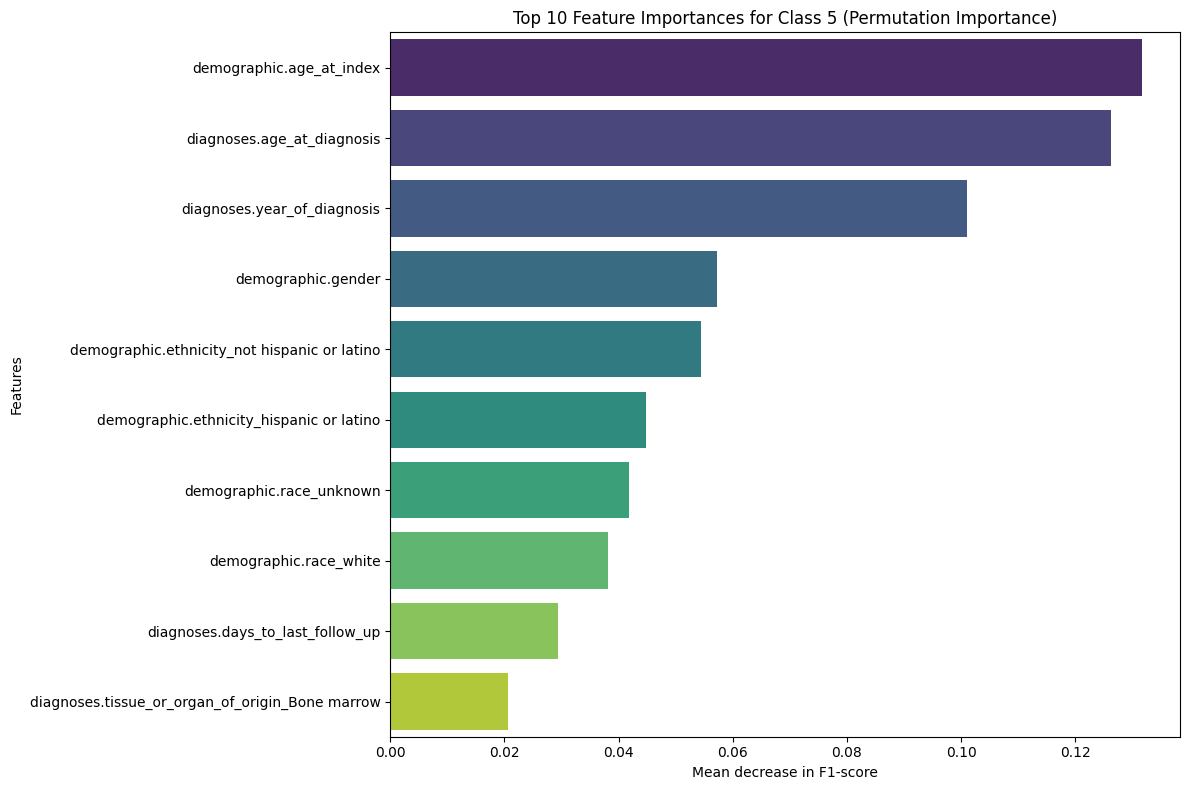


Calculating permutation importance for class 6...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Top 10 features for class 6:
demographic.year_of_birth                                       0.162420
diagnoses.year_of_diagnosis                                     0.126080
diagnoses.age_at_diagnosis                                      0.058664
demographic.age_at_index                                        0.031404
demographic.race_unknown                                        0.018734
demographic.country_of_residence_at_enrollment_United States    0.014318
demographic.gender                                              0.011341
demographic.race_white                                          0.009535
diagnoses.tissue_or_organ_of_origin_Bone marrow                 0.005080
demographic.race_american indian or alaska native               0.004567
dtype: float64


/tmp/ipykernel_368/3744880176.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


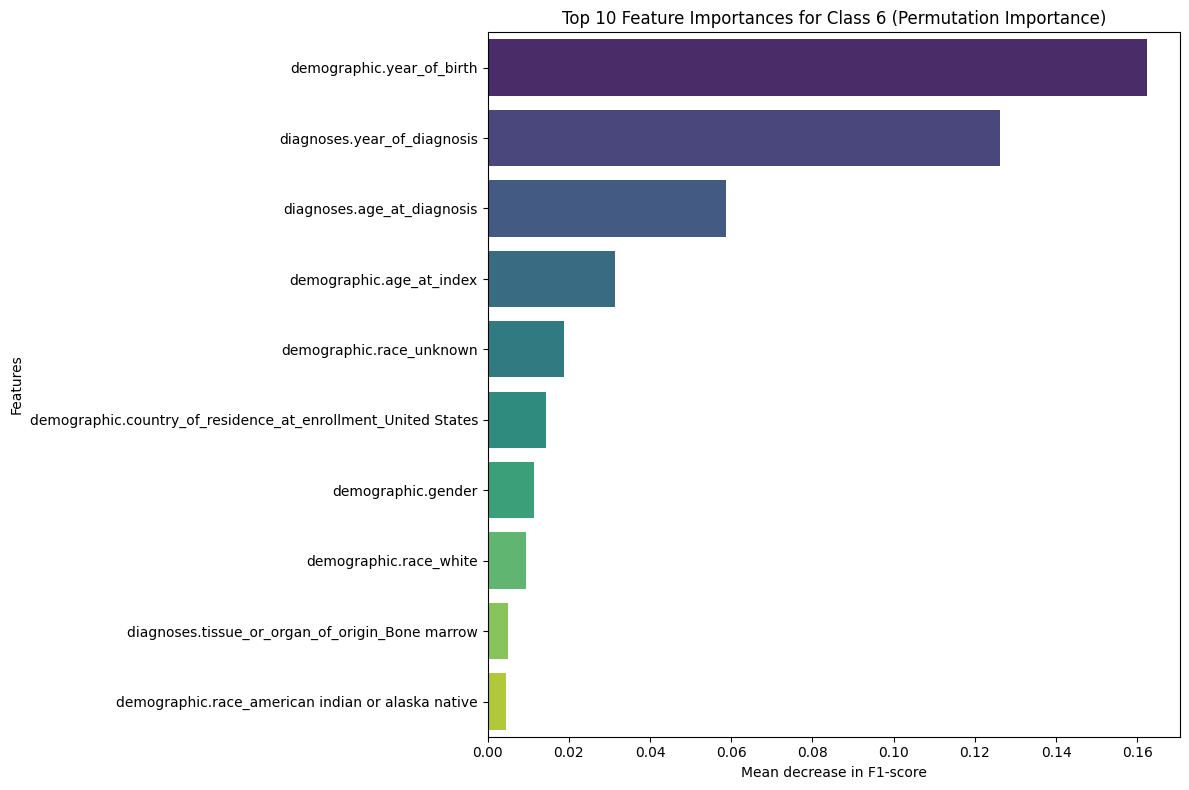


Calculating permutation importance for class 7...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Top 10 features for class 7:
demographic.year_of_birth                                   0.057727
demographic.age_at_index                                    0.045028
diagnoses.year_of_diagnosis                                 0.034570
diagnoses.age_at_diagnosis                                  0.029692
demographic.race_unknown                                    0.013210
demographic.race_white                                      0.007854
demographic.country_of_residence_at_enrollment_Australia    0.007437
diagnoses.tissue_or_organ_of_origin_Bone marrow             0.005643
demographic.ethnicity_hispanic or latino                    0.005338
demographic.ethnicity_not hispanic or latino                0.005127
dtype: float64


/tmp/ipykernel_368/3744880176.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


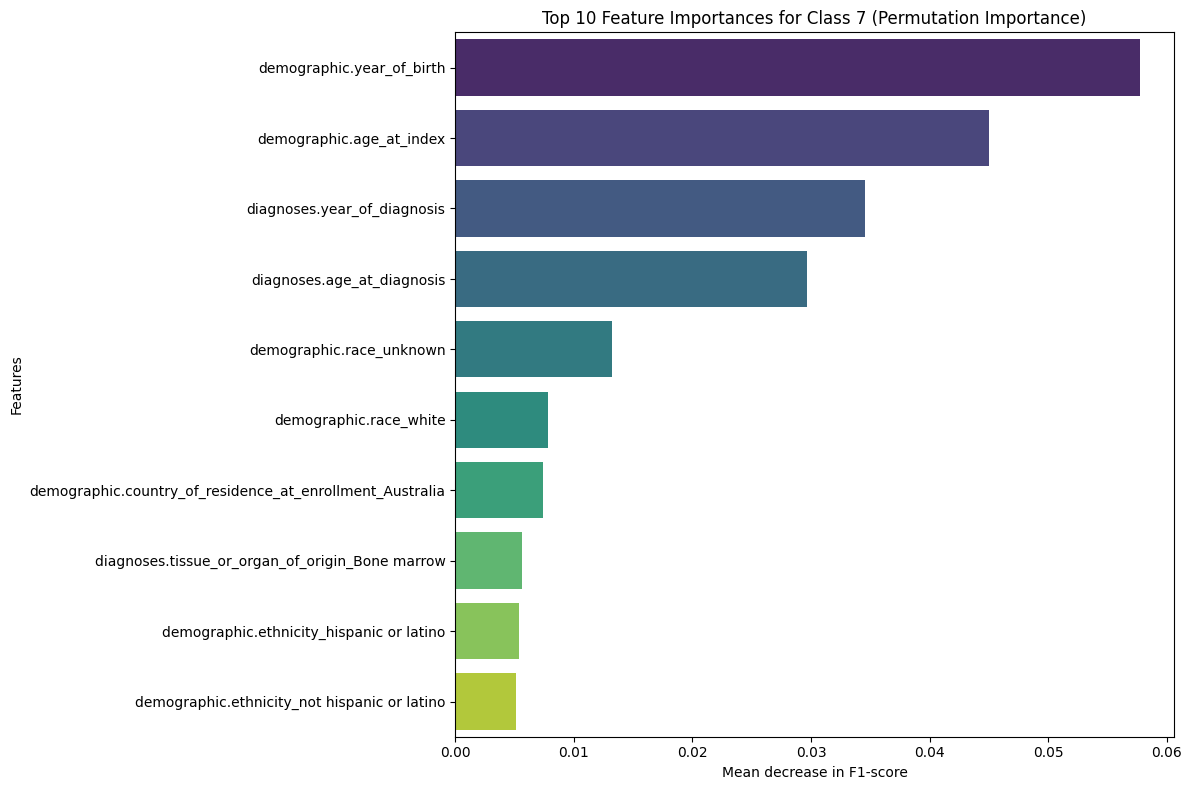

In [ ]:
# Only compute permutation importance for classes 5, 6, and 7
target_classes = [5, 6, 7]

# Store results for all classes
all_class_importances = {}

for cls in target_classes:
    print(f"\nCalculating permutation importance for class {cls}...")

    # Custom scorer for F1-score of the specific class
    def f1_scorer_single_class(y_true, y_pred):
        y_pred_labels = np.argmax(y_pred, axis=-1)
        return f1_score(y_true, y_pred_labels, labels=[cls], average='micro')

    scorer_single = make_scorer(f1_scorer_single_class)

    # Permutation importance
    results = permutation_importance(
        update_model,
        X_test_scaled_nn,
        y_test_nn,
        scoring=scorer_single,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Sort results
    sorted_idx = results.importances_mean.argsort()[::-1]
    feature_importances = pd.Series(
        results.importances_mean[sorted_idx],
        index=X_test_scaled_nn.columns[sorted_idx]
    )

    all_class_importances[cls] = feature_importances

    # Print top 10
    print(f"Top 10 features for class {cls}:")
    print(feature_importances.head(10))

    # Plot top 10
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x=feature_importances.head(10).values,
        y=feature_importances.head(10).index,
        palette='viridis'
    )
    plt.title(f"Top 10 Feature Importances for Class {cls} (Permutation Importance)")
    plt.xlabel("Mean decrease in F1-score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

#5-Year survival and treatment type

Random Forest

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   cases.case_id                                   1510 non-null   object 
 1   cases.disease_type                              1510 non-null   object 
 2   demographic.age_at_index                        1510 non-null   int64  
 3   demographic.country_of_residence_at_enrollment  1510 non-null   object 
 4   demographic.ethnicity                           1510 non-null   object 
 5   demographic.gender                              1510 non-null   object 
 6   demographic.race                                1510 non-null   object 
 7   demographic.vital_status                        1510 non-null   object 
 8   demographic.year_of_birth                       1510 non-null   int64  
 9   demographic.year_of_death                

In [ ]:
df['death_years'].unique()

array(['1', '0'], dtype=object)

Dropped diagnosis.days_to_last_follow_up since it would not be a predictor of negative outcome and rather a result of it.

In [ ]:
#Remove single items of the highly correlated pairs
columns_to_drop_from_df = [
    'cases.case_id',
    'cases.disease_type',
    'demographic.year_of_death',
    'demographic.vital_status',
    'demographic.age_at_index',
    'demographic.year_of_birth',
    'diagnoses.days_to_last_follow_up'
]

df_survival = df_survival.drop(columns=columns_to_drop_from_df, errors='ignore')
print(f"Columns dropped from df: {columns_to_drop_from_df}")
df_survival.info()

Columns dropped from df: ['cases.case_id', 'cases.disease_type', 'demographic.year_of_death', 'demographic.vital_status', 'demographic.age_at_index', 'demographic.year_of_birth', 'diagnoses.days_to_last_follow_up']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 78 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   demographic.gender                                                                                                                          1510 non-null   int64  
 1   diagnoses.age_at_diagnosis                                                                                                                  1510 non-null   int64  
 2

One-hot encode diagnosis

In [ ]:
# Create a copy of the DataFrame for one-hot encoding
df_survival_one_hot = df_survival.copy()

# Columns for one-hot encoding
one_hot_cols = [
    'diagnoses.primary_diagnosis'
]

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply one-hot encoding
encoded_features = encoder.fit_transform(df_survival_one_hot[one_hot_cols])

# Create a DataFrame from the encoded features with appropriate column names
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(one_hot_cols), index=df_survival_one_hot.index)

# Drop the original categorical columns and concatenate the new encoded columns
df_survival_one_hot = df_survival_one_hot.drop(columns=one_hot_cols)
df_survival_one_hot = pd.concat([df_survival_one_hot, encoded_df], axis=1)

# Display the head of the new DataFrame
print("Head of the DataFrame after one-hot encoding and binary conversion:")
display(df_survival_one_hot.head())

# Display the info of the new DataFrame to show column types and counts
print("\nInfo of the DataFrame after one-hot encoding and binary conversion:")
df_survival_one_hot.info()

Head of the DataFrame after one-hot encoding and binary conversion:


,demographic.gender,diagnoses.age_at_diagnosis,diagnoses.year_of_diagnosis,treatments.days_to_treatment_end,treatments.days_to_treatment_start,treatments.number_of_cycles,treatments.treatment_outcome,death_years,demographic.country_of_residence_at_enrollment_Albania,demographic.country_of_residence_at_enrollment_Australia,...,diagnoses.primary_diagnosis_Common precursor B ALL,"diagnoses.primary_diagnosis_Leukemia, NOS","diagnoses.primary_diagnosis_Lymphoid leukemia, NOS","diagnoses.primary_diagnosis_Neoplasm, uncertain whether benign or malignant","diagnoses.primary_diagnosis_Osteosarcoma, NOS",diagnoses.primary_diagnosis_Precursor B-cell lymphoblastic leukemia,"diagnoses.primary_diagnosis_Precursor cell lymphoblastic leukemia, NOS","diagnoses.primary_diagnosis_Precursor cell lymphoblastic leukemia, not phenotyped",diagnoses.primary_diagnosis_Subacute lymphoid leukemia,diagnoses.primary_diagnosis_Unknown
0,0,2231,2012,810,1,6,1,1,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,2492,2010,821,1,5,1,0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1026,2012,42,1,1,1,1,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,5675,2007,862,2,5,1,1,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1040,2010,794,1,5,1,1,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Info of the DataFrame after one-hot encoding and binary conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 91 columns):
 #   Column                                                                                                                                      Non-Null Count  Dtype  
---  ------                                                                                                                                      --------------  -----  
 0   demographic.gender                                                                                                                          1510 non-null   int64  
 1   diagnoses.age_at_diagnosis                                                                                                                  1510 non-null   int64  
 2   diagnoses.year_of_diagnosis                                                                                                                 151

In [ ]:
# Define features (X) and target (y)
X = df_survival_one_hot.drop('death_years', axis=1)
y = df_survival_one_hot['death_years']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Original training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("\nRandom Forest Classifier Performance (with SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original training set class distribution:
death_years
1    1003
0      54
Name: count, dtype: int64

Resampled training set class distribution:
death_years
1    1003
0    1003
Name: count, dtype: int64

Random Forest Classifier Performance (with SMOTE):
Accuracy: 0.9404

Confusion Matrix:
[[  0  23]
 [  4 426]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.95      0.99      0.97       430

    accuracy                           0.94       453
   macro avg       0.47      0.50      0.48       453
weighted avg       0.90      0.94      0.92       453



In [ ]:
# -----------------------------
# 1. Prepare data
# -----------------------------

X = df_survival_one_hot.drop('death_years', axis=1)
y = df_survival_one_hot['death_years']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Original training set class distribution:")
print(y_train.value_counts())

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

# -----------------------------
# 2. Define Random Forest + tuning grid
# -----------------------------
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',   # better for imbalanced classes
    n_jobs=-1,
    verbose=2
)

print("\nStarting Random Forest hyperparameter tuning...")
grid.fit(X_train_resampled, y_train_resampled)

# -----------------------------
# 3. Best model + evaluation
# -----------------------------
print("\nBest Parameters:")
print(grid.best_params_)

print(f"\nBest CV Score (F1-macro): {grid.best_score_:.4f}")

best_rf = grid.best_estimator_

# Predict on test set
y_pred = best_rf.predict(X_test)

print("\nRandom Forest Performance (Tuned):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Original training set class distribution:
death_years
1    1003
0      54
Name: count, dtype: int64

Resampled training set class distribution:
death_years
1    1003
0    1003
Name: count, dtype: int64

Starting Random Forest hyperparameter tuning...
Fitting 3 folds for each of 324 candidates, totalling 972 fits

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}

Best CV Score (F1-macro): 0.9726

Random Forest Performance (Tuned):
Accuracy: 0.9404

Confusion Matrix:
[[  0  23]
 [  4 426]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.95      0.99      0.97       430

    accuracy                           0.94       453
   macro avg       0.47      0.50      0.48       453
weighted avg       0.90      0.94      0.92       453



Top 5 Most Important Features for predicting 5 year Survival:
treatments.reason_treatment_ended_Disease Progression            0.144714
treatments.reason_treatment_ended_Course of Therapy Completed    0.119890
treatments.days_to_treatment_end                                 0.115521
diagnoses.age_at_diagnosis                                       0.054460
demographic.ethnicity_not hispanic or latino                     0.045621
dtype: float64


/tmp/ipykernel_368/424333140.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')


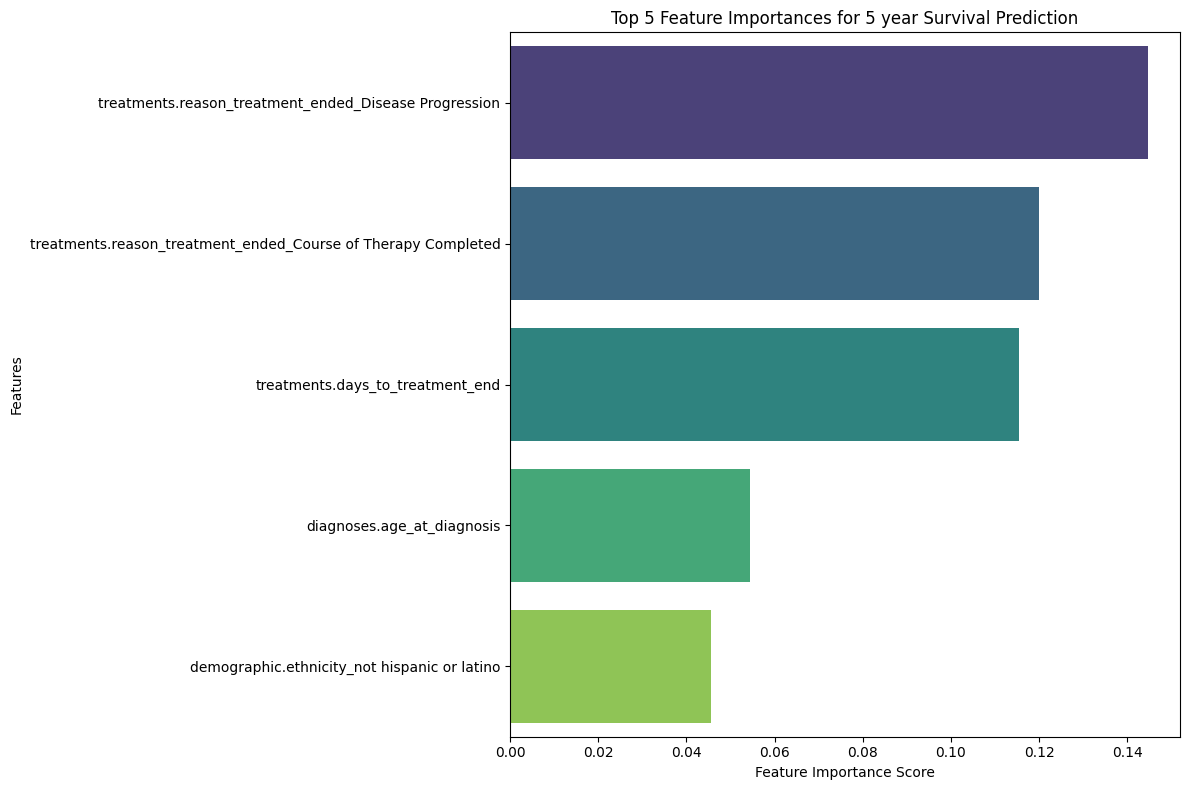

In [ ]:
# Get feature importances from the trained Random Forest classifier
feature_importances = best_rf.feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
feature_importances_series = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance in descending order
sorted_features = feature_importances_series.sort_values(ascending=False)

# Display the top 5 most important features
print("Top 5 Most Important Features for predicting 5 year Survival:")
print(sorted_features.head(5))

# Plot the top 5 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_features.head(5).values, y=sorted_features.head(5).index, palette='viridis')
plt.title('Top 5 Feature Importances for 5 year Survival Prediction')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

XGBoost

In [ ]:
X = df_survival_one_hot.drop('death_years', axis=1)
y = df_survival_one_hot['death_years'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set class distribution:")
print(y_train.value_counts())

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic', # Changed for binary classification
        eval_metric='logloss',       # Changed to a common binary metric
        # num_class is not needed for binary:logistic
        random_state=42,
        tree_method='hist'
    ))
])

param_dist = {
    'xgb__n_estimators': [200, 400, 600],
    'xgb__max_depth': [3, 5, 7, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__gamma': [0, 0.1, 0.3, 0.5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_macro',       # best for imbalanced classes
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("\nStarting XGBoost hyperparameter tuning...")
search.fit(X_train, y_train)

print("\nBest Parameters:")
print(search.best_params_)

print(f"\nBest CV Score (F1-macro): {search.best_score_:.4f}")

best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)

print("\nXGBoost Performance (Tuned):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training set class distribution:
death_years
1    1003
0      54
Name: count, dtype: int64

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 600, 'xgb__min_child_weight': 1, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.6}

Best CV Score (F1-macro): 0.6707

XGBoost Performance (Tuned):
Accuracy: 0.9316

Confusion Matrix:
[[  6  17]
 [ 14 416]]

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.26      0.28        23
           1       0.96      0.97      0.96       430

    accuracy                           0.93       453
   macro avg       0.63      0.61      0.62       453
weighted avg       0.93      0.93      0.93       453



Top 10 Most Important Features for predicting Vital Status (XGBoost):
treatments.reason_treatment_ended_Course of Therapy Completed                       0.161654
treatments.reason_treatment_ended_Disease Progression                               0.136863
treatments.regimen_or_line_of_therapy_B-ALL Non-Down Syndrome  Induction Therapy    0.078584
treatments.reason_treatment_ended_Other                                             0.059452
treatments.reason_treatment_ended_Withdrawal by Subject                             0.057624
treatments.number_of_cycles                                                         0.037411
treatments.days_to_treatment_end                                                    0.033117
demographic.ethnicity_not hispanic or latino                                        0.023666
demographic.ethnicity_hispanic or latino                                            0.022359
demographic.race_white                                                              0.021863


/tmp/ipykernel_368/2276040892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_sorted_features.head(10).values, y=xgb_sorted_features.head(10).index, palette='magma')


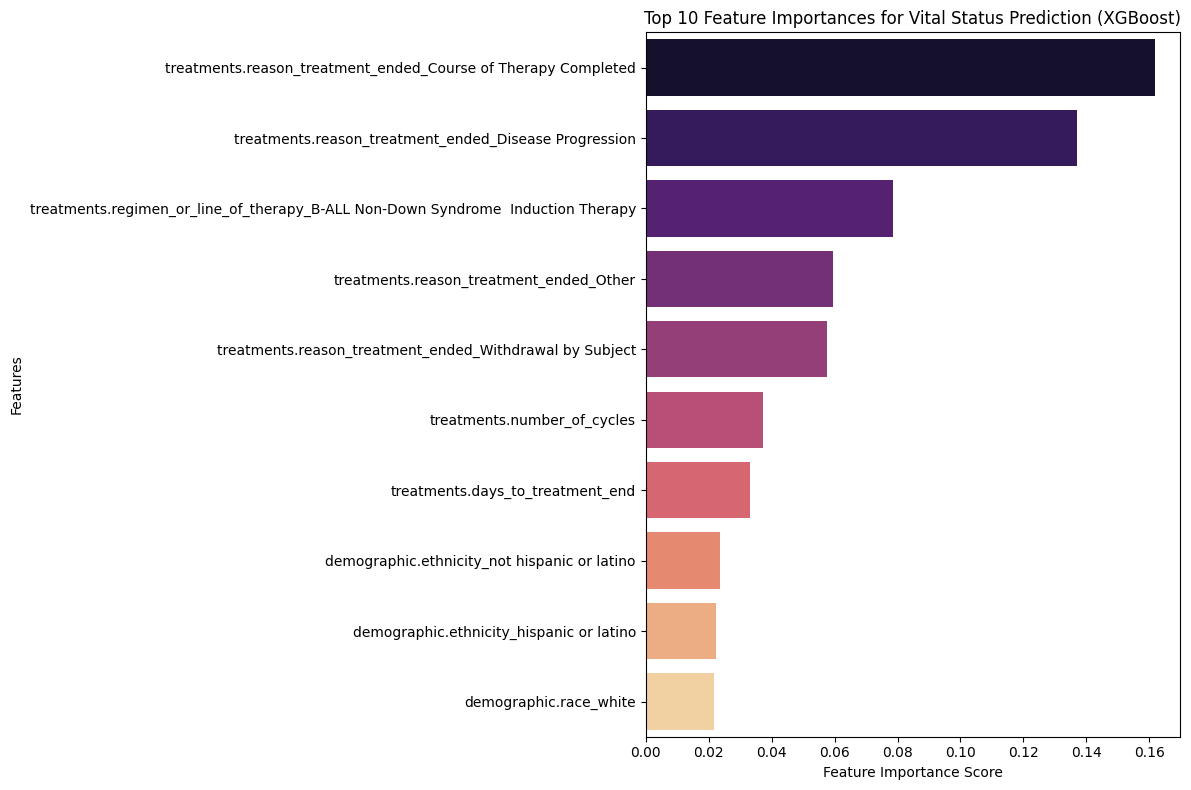

In [ ]:
xgb_feature_importances = best_xgb.named_steps['xgb'].feature_importances_

# Create a Pandas Series for better visualization and sorting, using the current X.columns
xgb_feature_importances_series = pd.Series(xgb_feature_importances, index=X.columns)

# Sort the features by importance in descending order
xgb_sorted_features = xgb_feature_importances_series.sort_values(ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features for predicting Vital Status (XGBoost):")
print(xgb_sorted_features.head(10))

# Plot the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_sorted_features.head(10).values, y=xgb_sorted_features.head(10).index, palette='magma')
plt.title('Top 10 Feature Importances for Vital Status Prediction (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Neural Network

In [ ]:
X_nn = df_survival_one_hot.drop('death_years', axis=1)
y_nn = df_survival_one_hot['death_years'].astype(int)

# Split the data into training and testing sets
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_nn, y_nn, test_size=0.3, random_state=42, stratify=y_nn)

print("Original training set class distribution for NN:")
print(y_train_nn.value_counts())

# Apply SMOTE to the training data for class imbalance
sm_nn = SMOTE(random_state=42, k_neighbors=2)
X_train_resampled_nn, y_train_resampled_nn = sm_nn.fit_resample(X_train_nn, y_train_nn)

print("\nResampled training set class distribution for NN:")
print(y_train_resampled_nn.value_counts())

# Standardize numerical features
scaler_nn = StandardScaler()

# Identify numerical columns for scaling
numerical_cols_nn = X_train_resampled_nn.select_dtypes(include=np.number).columns

# Apply scaling
X_train_scaled_nn = X_train_resampled_nn.copy()
X_test_scaled_nn = X_test_nn.copy()

X_train_scaled_nn[numerical_cols_nn] = scaler_nn.fit_transform(X_train_resampled_nn[numerical_cols_nn])
X_test_scaled_nn[numerical_cols_nn] = scaler_nn.transform(X_test_nn[numerical_cols_nn])

print("\nData preparation complete. X_train_scaled_nn and X_test_scaled_nn are ready for Neural Network.")

Original training set class distribution for NN:
death_years
1    1003
0      54
Name: count, dtype: int64

Resampled training set class distribution for NN:
death_years
1    1003
0    1003
Name: count, dtype: int64

Data preparation complete. X_train_scaled_nn and X_test_scaled_nn are ready for Neural Network.


In [ ]:
from itertools import product

# --- 3. Manual Hyperparameter Tuning Loop ---

# Define the parameter grid for tuning
# Note: 'model__' prefixes are removed for direct use in create_nn_model
param_grid_nn_direct = {
    'num_hidden_layers': [1, 2],
    'num_neurons': [64, 128],
    'learning_rate': [0.001, 0.01],
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop'],
    'batch_size': [32, 64],
    'epochs': [20, 30] # Reduced epochs for faster execution during tuning
}

_best_accuracy_global = 0
_best_params_global = None
_best_nn_model_global = None # To store the actual Keras model
_best_history_global = None # To store the training history of the best model

# Get all parameter combinations
keys = param_grid_nn_direct.keys()
values = param_grid_nn_direct.values()
param_combinations = list(product(*values))

print("Starting manual hyperparameter tuning loop for Neural Network. This may take some time...")
print(f"Total combinations to test: {len(param_combinations)}")

for i, params_tuple in enumerate(param_combinations):
    current_params = dict(zip(keys, params_tuple))

    # Extract parameters for model creation
    num_hidden_layers = current_params['num_hidden_layers']
    num_neurons = current_params['num_neurons']
    learning_rate = current_params['learning_rate']
    activation = current_params['activation']
    optimizer_name = current_params['optimizer'] # Renamed to avoid conflict with model instance

    # Extract parameters for model fitting
    batch_size = current_params['batch_size']
    epochs = current_params['epochs']

    # Create the Keras model
    model = create_nn_model(
        num_hidden_layers=num_hidden_layers,
        num_neurons=num_neurons,
        learning_rate=learning_rate,
        activation=activation,
        optimizer=optimizer_name
    )

    # Train the model and capture history
    # Use the resampled training data
    history = model.fit(X_train_scaled_nn, y_train_resampled_nn,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0,
                        validation_data=(X_test_scaled_nn, y_test_nn)) # Add validation data

    # Evaluate the model on the test set
    # Using X_test_scaled_nn and y_test_nn as a validation proxy for tuning
    _, accuracy = model.evaluate(X_test_scaled_nn, y_test_nn, verbose=0)

    # Check if this is the best model so far
    if accuracy > _best_accuracy_global:
        _best_accuracy_global = accuracy
        _best_params_global = current_params
        _best_nn_model_global = model # Store the actual Keras model
        _best_history_global = history # Store the history of the best model

print("\nManual hyperparameter tuning complete.")

print("\nBest parameters found:")
print(_best_params_global)
print(f"Best accuracy achieved: {_best_accuracy_global:.4f}")

Starting manual hyperparameter tuning loop for Neural Network. This may take some time...
Total combinations to test: 128

Manual hyperparameter tuning complete.

Best parameters found:
{'num_hidden_layers': 2, 'num_neurons': 64, 'learning_rate': 0.01, 'activation': 'relu', 'optimizer': 'adam', 'batch_size': 32, 'epochs': 30}
Best accuracy achieved: 0.9404


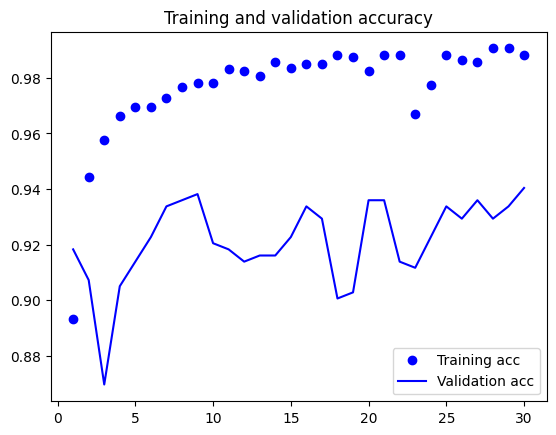

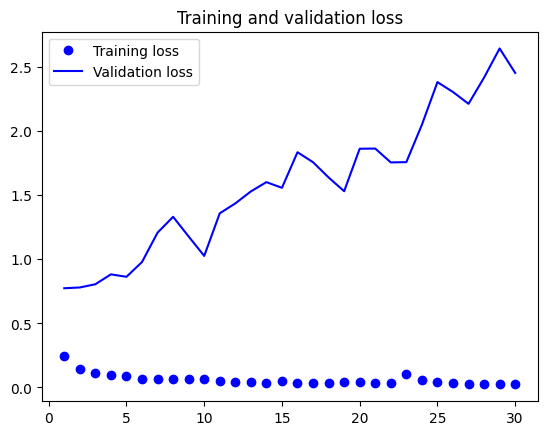

In [ ]:
acc = _best_history_global.history['accuracy']
val_acc = _best_history_global.history['val_accuracy']
loss = _best_history_global.history['loss']
val_loss = _best_history_global.history['val_loss']

epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Best Epoch at 6

In [ ]:
update_model = create_nn_model(
        num_hidden_layers=2,
        num_neurons=64,
        learning_rate=0.01,
        activation='relu',
        optimizer='rmsprop'
    )

update_model.fit(X_train_scaled_nn, y_train_resampled_nn,
                        epochs=6,
                        batch_size=32,
                        verbose=0,
                        validation_data=(X_test_scaled_nn, y_test_nn))

_, update_accuracy = update_model.evaluate(X_test_scaled_nn, y_test_nn, verbose=0)
print(f"Best accuracy achieved: {update_accuracy:.4f}")

Best accuracy achieved: 0.9249


In [ ]:
# --- 4. Evaluate the best Neural Network model ---

print("\nBest parameters found by manual tuning:")
print(update_model)

# Get the best estimator (the trained model with best parameters)
best_nn_model = update_model

# Make predictions on the scaled test set
y_pred_nn = np.argmax(best_nn_model.predict(X_test_scaled_nn), axis=-1)

# Evaluate the model
print("\nNeural Network Classifier Performance (with SMOTE, Scaling, and Tuned Parameters):")
print(f"Accuracy: {accuracy_score(y_test_nn, y_pred_nn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_nn, y_pred_nn))
print("\nClassification Report:")
print(classification_report(y_test_nn, y_pred_nn))


Best parameters found by manual tuning:
<Sequential name=sequential_978, built=True>
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Neural Network Classifier Performance (with SMOTE, Scaling, and Tuned Parameters):
Accuracy: 0.9249

Confusion Matrix:
[[  1  22]
 [ 12 418]]

Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.04      0.06        23
           1       0.95      0.97      0.96       430

    accuracy                           0.92       453
   macro avg       0.51      0.51      0.51       453
weighted avg       0.91      0.92      0.91       453




Calculating permutation importance for class 0...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Top 10 features for class 0:
treatments.reason_treatment_ended_Disease Progression                                                                                         0.050150
treatments.regimen_or_line_of_therapy_B-ALL Average Risk Post-Induction/Pre-Maintenance Therapy                                               0.050150
treatments.number_of_cycles                                                                                                                   0.028790
diagnoses.primary_diagnosis_Leukemia, NOS                                                                                                     0.008713
treatments.treatment_outcome                                                                                                                  0.006757
treatments.regimen_or_line_of_therapy_B-ALL Average Risk - Arm A Maintenance Therapy                                         

/tmp/ipykernel_368/934513419.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


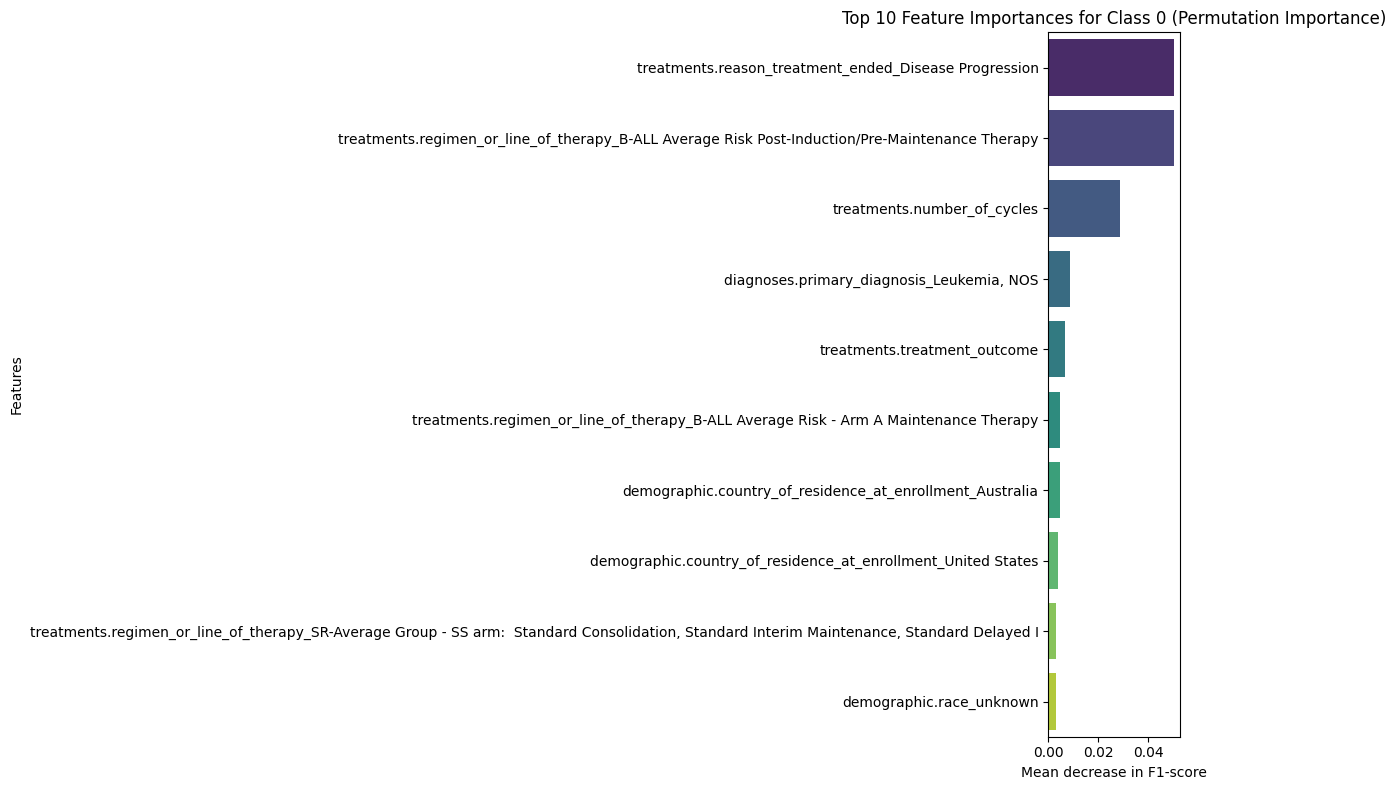


Calculating permutation importance for class 1...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Top 10 features for class 1:
diagnoses.year_of_diagnosis                                                                                                                   0.008026
demographic.ethnicity_not hispanic or latino                                                                                                  0.005893
treatments.days_to_treatment_start                                                                                                            0.005801
demographic.ethnicity_hispanic or latino                                                                                                      0.005217
diagnoses.age_at_diagnosis                                                                                                                    0.004945
treatments.reason_treatment_ended_Disease Progression                                                                        

/tmp/ipykernel_368/934513419.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


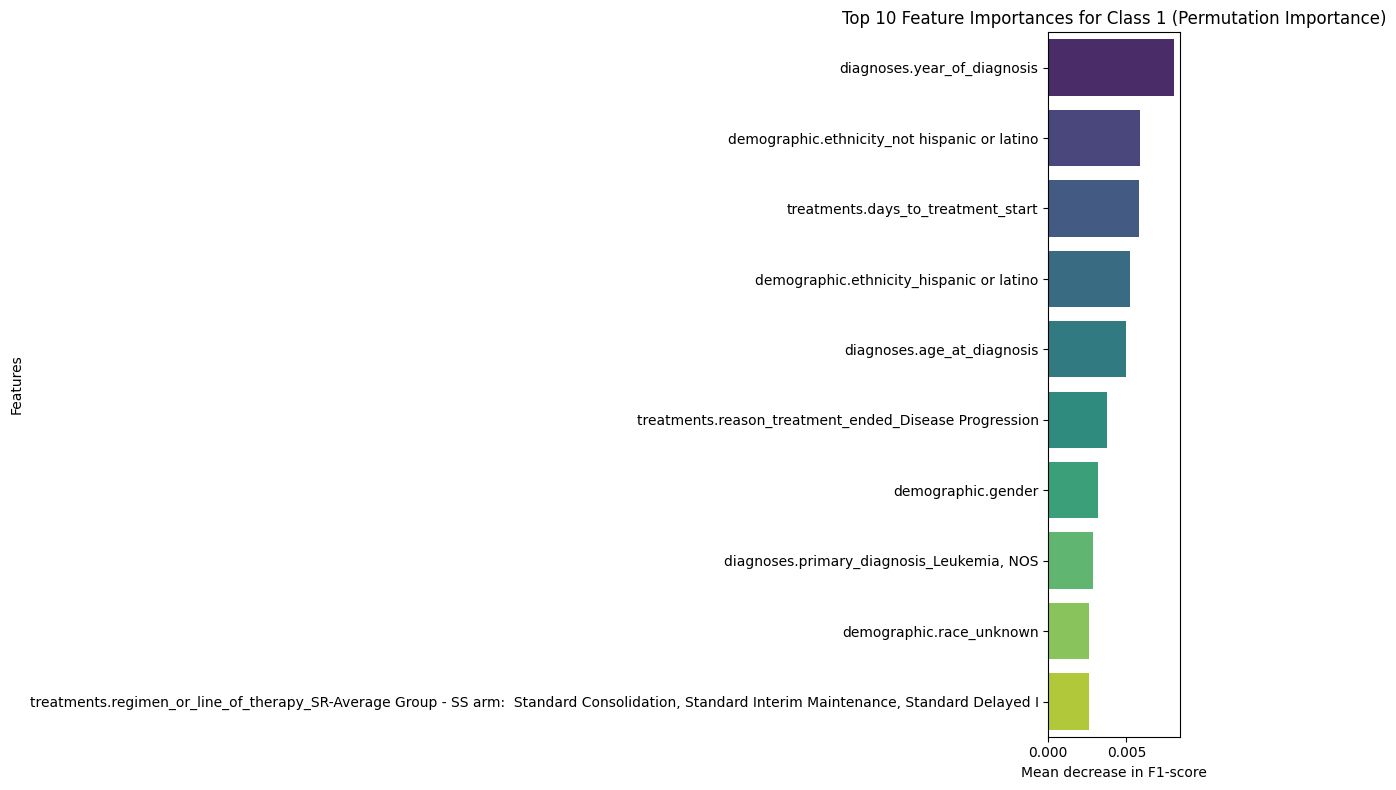

In [ ]:
# Only compute permutation importance for classes
target_classes = [0, 1]

# Store results for all classes
all_class_importances = {}

for cls in target_classes:
    print(f"\nCalculating permutation importance for class {cls}...")

    # Custom scorer for F1-score of the specific class
    def f1_scorer_single_class(y_true, y_pred):
        y_pred_labels = np.argmax(y_pred, axis=-1)
        return f1_score(y_true, y_pred_labels, labels=[cls], average='micro')

    scorer_single = make_scorer(f1_scorer_single_class)

    # Permutation importance
    results = permutation_importance(
        update_model,
        X_test_scaled_nn,
        y_test_nn,
        scoring=scorer_single,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Sort results
    sorted_idx = results.importances_mean.argsort()[::-1]
    feature_importances = pd.Series(
        results.importances_mean[sorted_idx],
        index=X_test_scaled_nn.columns[sorted_idx]
    )

    all_class_importances[cls] = feature_importances

    # Print top 10
    print(f"Top 10 features for class {cls}:")
    print(feature_importances.head(10))

    # Plot top 10
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x=feature_importances.head(10).values,
        y=feature_importances.head(10).index,
        palette='viridis'
    )
    plt.title(f"Top 10 Feature Importances for Class {cls} (Permutation Importance)")
    plt.xlabel("Mean decrease in F1-score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()